# 0. Setting up development environment

In the cell below the required packages for running this notebook is installed.

In [ ]:
! pip install pyspark
! pip install numpy
! pip install pandas
! pip install matplotlib
! pip install jupyter
! pip install scikit-learn
! pip install scipy
! pip install seaborn
! pip install requests

# 1. Setting up Apache Spark

In the following cell, all necessary packages are imported to be used later on. Then, the spark instance is created and configured, the instance is to be run
 on a local machine, all the configuration can be modified to be run on different system configs. Also, a cluster can be used instead of local instance. This
  is can be done simply by modifying the URL in the spark configuration cell.

In [ ]:
import os
import os.path
import shutil
from typing import List, Union, Optional, Tuple
from warnings import filterwarnings
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyspark
import requests
from pyspark.ml.recommendation import ALS
from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.ml.evaluation import RegressionEvaluator

filterwarnings(action="ignore")

In [ ]:
high_res = True
general_fig_size = (120, 80) if high_res else (12, 8)

In [ ]:
conf = pyspark.SparkConf()

conf.setMaster("local[*]")

conf.setAppName("book-recommendation-system")
conf.set("spark.authenticate", False)
conf.set("spark.dynamicAllocation.enabled", True)
conf.set("spark.executor.instances", "4")
conf.set("spark.executor.memory", "10g")
conf.set("spark.driver.memory", "6g")
conf.set("spark.executor.memoryOverhead", "10g")

sc = pyspark.SparkContext(conf=conf)
sc.setLogLevel("ERROR")

23/06/26 16:51:26 WARN Utils: Your hostname, legion-7 resolves to a loopback address: 127.0.1.1; using 192.168.0.11 instead (on interface wlp0s20f3)
23/06/26 16:51:26 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
23/06/26 16:51:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [ ]:
# connect to master node at the given url
spark = SparkSession(sc)

In [ ]:
# show the information about the spark active session.
spark.getActiveSession()

---

# 2. Loading data

In this section, all the files of the dataset are downloaded from the internet and saved to the disk. After that, they are read from the disk and loaded into
 spark dataframes.

In [ ]:
data_dir = "data"


def is_dataset_ready():
    """
    Check whether the dataset files are ready to be used.

    Returns
    -------
    bool
        Whether the dataset files are ready or not.
    """
    return (
        os.path.exists(f"{data_dir}/BX-Book-Ratings.csv")
        and os.path.exists(f"{data_dir}/BX-Books.csv")
        and os.path.exists(f"{data_dir}/BX-Users.csv")
    )


# check if the base dir exists
if not os.path.exists(data_dir):
    os.mkdir(data_dir)

# if dataset is not ready, it needs to be downloaded and extracted.
if not is_dataset_ready():
    # remove the base dir with all its contents and create the directory again without the files.
    shutil.rmtree(data_dir)
    os.mkdir(data_dir)

    # download the dataset archive from the dataset website
    r = requests.get(
        "http://www2.informatik.uni-freiburg.de/~cziegler/BX/BX-CSV-Dump.zip"
    )
    # write the dataset archive into the base data directory with its original name
    with open(f"{data_dir}/BX-CSV-Dump.zip", "wb") as f:
        f.write(r.content)

    # extract the downloaded archive into the base directory
    with ZipFile(f"{data_dir}/BX-CSV-Dump.zip", "r") as zip_file:
        zip_file.extractall(f"{data_dir}/")

    # check again if the dataset files are ready
    if not is_dataset_ready():
        raise Exception("Dataset files could not be extracted successfully!")

There are 3 files in the base directory, the `BX-Books.csv` file contains all information about all the books, the `BX-Users.csv` contains all information
about the users, and the `BX-Book-Rating.csv` file stores the rating information.

All three file are read from the disk and loaded into pyspark dataframes in the following cells.

In [ ]:
# read the books dataset, skip if there is any bad lines in the source file.
df_books = spark.createDataFrame(
    pd.read_csv(
        f"{data_dir}/BX-Books.csv",
        delimiter=";",
        on_bad_lines="skip",
        encoding="ISO-8859-1",
    )
)
books_count = df_books.count()

# show some basic information about the loaded dataframe
print(f"Number of books: {books_count}")
print(f"Number of features in the books dataframe: {len(df_books.columns)}")

Number of books: 271360
Number of features in the books dataframe: 8


In [ ]:
# print the schema of the books dataframe to take a look at the loaded data types
df_books.printSchema()

root
 |-- ISBN: string (nullable = true)
 |-- Book-Title: string (nullable = true)
 |-- Book-Author: string (nullable = true)
 |-- Year-Of-Publication: string (nullable = true)
 |-- Publisher: string (nullable = true)
 |-- Image-URL-S: string (nullable = true)
 |-- Image-URL-M: string (nullable = true)
 |-- Image-URL-L: string (nullable = true)



In [ ]:
# show the top-10 records
df_books.show(10)

+----------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+
|      ISBN|          Book-Title|         Book-Author|Year-Of-Publication|           Publisher|         Image-URL-S|         Image-URL-M|         Image-URL-L|
+----------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+
|0195153448| Classical Mythology|  Mark P. O. Morford|               2002|Oxford University...|http://images.ama...|http://images.ama...|http://images.ama...|
|0002005018|        Clara Callan|Richard Bruce Wright|               2001|HarperFlamingo Ca...|http://images.ama...|http://images.ama...|http://images.ama...|
|0060973129|Decision in Normandy|        Carlo D'Este|               1991|     HarperPerennial|http://images.ama...|http://images.ama...|http://images.ama...|
|0374157065|Flu: The Story of...|    Gina Bari

In [ ]:
# load the users dataset
df_users = spark.createDataFrame(
    pd.read_csv(
        f"{data_dir}/BX-Users.csv",
        delimiter=";",
        on_bad_lines="skip",
        encoding="ISO-8859-1",
    )
)
users_count = df_users.count()

# show some basic info about the loaded dataframe
print(f"Number of users: {users_count}")
print(f"Number of features in the users dataframe: {len(df_users.columns)}")

Number of users: 278858
Number of features in the users dataframe: 3


In [ ]:
# print the schema of the loaded dataframe
df_users.printSchema()

root
 |-- User-ID: long (nullable = true)
 |-- Location: string (nullable = true)
 |-- Age: double (nullable = true)



In [ ]:
# show the top-10 rows of the users dataframe
df_users.show(10)

+-------+--------------------+----+
|User-ID|            Location| Age|
+-------+--------------------+----+
|      1|  nyc, new york, usa| NaN|
|      2|stockton, califor...|18.0|
|      3|moscow, yukon ter...| NaN|
|      4|porto, v.n.gaia, ...|17.0|
|      5|farnborough, hant...| NaN|
|      6|santa monica, cal...|61.0|
|      7| washington, dc, usa| NaN|
|      8|timmins, ontario,...| NaN|
|      9|germantown, tenne...| NaN|
|     10|albacete, wiscons...|26.0|
+-------+--------------------+----+
only showing top 10 rows



In [ ]:
# load the ratings dataframe
df_ratings = spark.createDataFrame(
    pd.read_csv(
        f"{data_dir}/BX-Book-Ratings.csv",
        delimiter=";",
        on_bad_lines="skip",
        encoding="ISO-8859-1",
    )
)
ratings_count = df_ratings.count()

# show some basic information about the ratings dataframe
print(f"Number of book ratings: {ratings_count}")
print(f"Number of features in the book ratings dataframe: {len(df_ratings.columns)}")

Number of book ratings: 1149780
Number of features in the book ratings dataframe: 3


In [ ]:
# print the schema of the ratings dataframe
df_ratings.printSchema()

root
 |-- User-ID: long (nullable = true)
 |-- ISBN: string (nullable = true)
 |-- Book-Rating: long (nullable = true)



In [ ]:
# print the top-10 rows of the dataframe
df_ratings.show(10)

+-------+----------+-----------+
|User-ID|      ISBN|Book-Rating|
+-------+----------+-----------+
| 276725|034545104X|          0|
| 276726|0155061224|          5|
| 276727|0446520802|          0|
| 276729|052165615X|          3|
| 276729|0521795028|          6|
| 276733|2080674722|          0|
| 276736|3257224281|          8|
| 276737|0600570967|          6|
| 276744|038550120X|          7|
| 276745| 342310538|         10|
+-------+----------+-----------+
only showing top 10 rows



---

# 3. Data Cleaning

In this section, first a few function are declared to facilitate the checking process of a given dataframe, and some other are meant for visualization
purposes. These function are used to clean the dataframes so they could be used in the later sections.

In [ ]:
def check_distinct_values(
    df: pyspark.sql.DataFrame,
    column_name: str,
    sort_by_count: bool = False,
    num: int = 1000,
    print_results: bool = True,
) -> Optional[pyspark.sql.DataFrame]:
    """
    Calculate distinct values in the given column of the given dataframe.

    Parameters
    ----------
    df : pyspark.sql.DataFrame
        Dataframe in query
    column_name : str
        Name of the column
    sort_by_count : bool, default : False
        Whether to sort the results by the distinct values count or not.
    num : int, default : 1000
        Max number of distinct values to check
    print_results : bool, default : True
        Whether to print the results or return the calculated dataframe.

    Returns
    -------
    pyspark.sql.DataFrame, optional
        A dataframe is returned if the `print_results` parameter is set to `False`, otherwise, the result is printed out.

    """
    _df = (
        df.select(column_name)
        .groupBy(column_name)
        .agg(F.count(column_name).alias("count"))
    )
    if sort_by_count:
        _df = _df.sort("count", ascending=False)
    else:
        _df = _df.sort(column_name, ascending=False)

    if print_results:
        return _df.show(num, truncate=False)
    else:
        return _df


def check_nan_values(
    df: pyspark.sql.DataFrame,
    column_names: Union[List[str], str] = None,
) -> None:
    """
    Check the `nan` values alongside the total count of it in each of the given columns.

    Parameters
    ----------
    df : pyspark.sql.DataFrame
        Dataframe in query.
    column_names : Union[List[str], str]
        Column name(s) to be checked.
    """
    if column_names is None:
        column_names = df.columns
    else:
        if isinstance(column_names, str):
            column_names = [column_names]
        elif isinstance(column_names, List):
            column_names = column_names
        else:
            raise ValueError("Invalid value for `cols`")

    df.select(
        [
            F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c)
            for c in column_names
        ]
    ).show(vertical=True)

## 3.1 Books Dataframe Cleaning
In this subsection, the books dataframe is cleaned.

In [ ]:
print(f"Columns: {list(df_books.columns)}")
df_books.show(5)

Columns: ['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Image-URL-S', 'Image-URL-M', 'Image-URL-L']
+----------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+
|      ISBN|          Book-Title|         Book-Author|Year-Of-Publication|           Publisher|         Image-URL-S|         Image-URL-M|         Image-URL-L|
+----------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+
|0195153448| Classical Mythology|  Mark P. O. Morford|               2002|Oxford University...|http://images.ama...|http://images.ama...|http://images.ama...|
|0002005018|        Clara Callan|Richard Bruce Wright|               2001|HarperFlamingo Ca...|http://images.ama...|http://images.ama...|http://images.ama...|
|0060973129|Decision in Normandy|        Carlo D'Este|               1991|   

Since the image urls are not going to be used for showing the recommendation in this project and they are not gonna be used in the algorithms, I will remove
them from the books datarame.

In [ ]:
# Drop URL columns
df_books = df_books.drop("Image-URL-S").drop("Image-URL-M").drop("Image-URL-L")

df_books.show(5)

+----------+--------------------+--------------------+-------------------+--------------------+
|      ISBN|          Book-Title|         Book-Author|Year-Of-Publication|           Publisher|
+----------+--------------------+--------------------+-------------------+--------------------+
|0195153448| Classical Mythology|  Mark P. O. Morford|               2002|Oxford University...|
|0002005018|        Clara Callan|Richard Bruce Wright|               2001|HarperFlamingo Ca...|
|0060973129|Decision in Normandy|        Carlo D'Este|               1991|     HarperPerennial|
|0374157065|Flu: The Story of...|    Gina Bari Kolata|               1999|Farrar Straus Giroux|
|0393045218|The Mummies of Ur...|     E. J. W. Barber|               1999|W. W. Norton &amp...|
+----------+--------------------+--------------------+-------------------+--------------------+
only showing top 5 rows



In [ ]:
# Checking for null values
check_nan_values(df_books)

-RECORD 0------------------
 ISBN                | 0   
 Book-Title          | 0   
 Book-Author         | 2   
 Year-Of-Publication | 0   
 Publisher           | 2   



Based on the above output, the `Publisher` and `Book-Author` columns both have **2** `nan` values that needs to be taken care of. The first step is
to check them to see what's wrong with the data. The following cell will do that.

In [ ]:
df_books.where(F.isnan("Book-Author")).show(truncate=False)

+----------+--------------------------------------------------------+-----------+-------------------+------------------------------+
|ISBN      |Book-Title                                              |Book-Author|Year-Of-Publication|Publisher                     |
+----------+--------------------------------------------------------+-----------+-------------------+------------------------------+
|0751352497|A+ Quiz Masters:01 Earth                                |NaN        |1999               |Dorling Kindersley            |
|9627982032|The Credit Suisse Guide to Managing Your Personal Wealth|NaN        |1995               |Edinburgh Financial Publishing|
+----------+--------------------------------------------------------+-----------+-------------------+------------------------------+



In [ ]:
df_books.where(F.isnan("Publisher")).show(truncate=False)

+----------+---------------+---------------+-------------------+---------+
|ISBN      |Book-Title     |Book-Author    |Year-Of-Publication|Publisher|
+----------+---------------+---------------+-------------------+---------+
|193169656X|Tyrant Moon    |Elaine Corvidae|2002               |NaN      |
|1931696993|Finders Keepers|Linnea Sinclair|2001               |NaN      |
+----------+---------------+---------------+-------------------+---------+



The rows with `nan` values can be dropped to solve the issue, or they could be replaced by some other value. I choose to consider the `nan` values as `Other`
in the mentioned columns.

In [ ]:
# replace the `nan` values in the `Book-Author` column with `Other`
df_books = df_books.withColumn(
    "Book-Author",
    F.when(F.isnan("Book-Author"), "Other").otherwise(F.col("Book-Author")),
)

In [ ]:
# check whether the above operation was successful or not.
df_books.where(F.isnan("Book-Author")).show(truncate=False)

+----+----------+-----------+-------------------+---------+
|ISBN|Book-Title|Book-Author|Year-Of-Publication|Publisher|
+----+----------+-----------+-------------------+---------+
+----+----------+-----------+-------------------+---------+



Both values have been replaced.

In [ ]:
# replace the `nan` values in the `Publisher` column with `Other`
df_books = df_books.withColumn(
    "Publisher", F.when(F.isnan("Publisher"), "Other").otherwise(F.col("Publisher"))
)

In [ ]:
# check whether the above operation was successful or not.
df_books.where(F.isnan("Publisher")).show(truncate=False)

+----+----------+-----------+-------------------+---------+
|ISBN|Book-Title|Book-Author|Year-Of-Publication|Publisher|
+----+----------+-----------+-------------------+---------+
+----+----------+-----------+-------------------+---------+



Both values have been replaced.

In [ ]:
# Checking for column Year-of-publication
check_distinct_values(df_books, "Year-Of-Publication", sort_by_count=False)

+-------------------+-----+
|Year-Of-Publication|count|
+-------------------+-----+
|Gallimard          |1    |
|DK Publishing Inc  |2    |
|2050               |2    |
|2038               |1    |
|2037               |1    |
|2030               |7    |
|2026               |1    |
|2024               |1    |
|2021               |1    |
|2020               |3    |
|2012               |1    |
|2011               |2    |
|2010               |2    |
|2008               |1    |
|2006               |3    |
|2005               |46   |
|2004               |5839 |
|2003               |14358|
|2002               |17627|
|2001               |17359|
|2000               |17232|
|1999               |17431|
|1998               |15766|
|1997               |14890|
|1996               |14030|
|1995               |13546|
|1994               |11796|
|1993               |10602|
|1992               |9906 |
|1991               |9389 |
|1990               |8660 |
|1989               |7936 |
|1988               

By taking a look at the above output, it can be seen that there are some invalid values. **0**, **Gallimard**, **DK Publishing Inc** are not valid values for
 the publication year column. So, they need to be checked.

In [ ]:
df_books.where(F.col("Year-Of-Publication") == "DK Publishing Inc").show(
    vertical=True,
    truncate=False,
)

-RECORD 0--------------------------------------------------------------------------------------------------------------------------
 ISBN                | 078946697X                                                                                                  
 Book-Title          | DK Readers: Creating the X-Men, How It All Began (Level 4: Proficient Readers)\";Michael Teitelbaum"        
 Book-Author         | 2000                                                                                                        
 Year-Of-Publication | DK Publishing Inc                                                                                           
 Publisher           | http://images.amazon.com/images/P/078946697X.01.THUMBZZZ.jpg                                                
-RECORD 1--------------------------------------------------------------------------------------------------------------------------
 ISBN                | 0789466953                                           

The above output shows that original data hasn't been correctly extracted and the `Book-Author` is a part of the `Book-Title` string. Also, the publication
year has been misplaced with the `Book-Author` column which can be fixed easily.

In [ ]:
df_books.where(F.col("Year-Of-Publication") == "Gallimard").show(
    vertical=True,
    truncate=False,
)

-RECORD 0---------------------------------------------------------------------------------------
 ISBN                | 2070426769                                                               
 Book-Title          | Peuple du ciel, suivi de 'Les Bergers\";Jean-Marie Gustave Le ClÃ?Â©zio" 
 Book-Author         | 2003                                                                     
 Year-Of-Publication | Gallimard                                                                
 Publisher           | http://images.amazon.com/images/P/2070426769.01.THUMBZZZ.jpg             



The `Book-Author` is misplaced in this case too. Both, issues can be fixed by replacing the invalid values with the correct ones from the printed outputs.
This procedure is done in the following cell in which the rows with the target `ISBN` values are found and modified.

In [ ]:
df_books = (
    df_books.withColumn(
        "Publisher",
        F.when(F.col("ISBN") == "078946697X", "DK Publishing Inc").otherwise(
            F.col("Publisher")
        ),
    )
    .withColumn(
        "Book-Title",
        F.when(
            F.col("ISBN") == "078946697X",
            "DK Readers: Creating the X-Men, How It All Began (Level 4: Proficient Readers)",
        ).otherwise(F.col("Book-Title")),
    )
    .withColumn(
        "Year-Of-Publication",
        F.when(F.col("ISBN") == "078946697X", 2000).otherwise(
            F.col("Year-Of-Publication")
        ),
    )
    .withColumn(
        "Book-Author",
        F.when(F.col("ISBN") == "078946697X", "Michael Teitelbaum").otherwise(
            F.col("Book-Author")
        ),
    )
)

df_books = (
    df_books.withColumn(
        "Publisher",
        F.when(F.col("ISBN") == "0789466953", "DK Publishing Inc").otherwise(
            F.col("Publisher")
        ),
    )
    .withColumn(
        "Year-Of-Publication",
        F.when(F.col("ISBN") == "0789466953", 2000).otherwise(
            F.col("Year-Of-Publication")
        ),
    )
    .withColumn(
        "Book-Title",
        F.when(
            F.col("ISBN") == "0789466953",
            "DK Readers: Creating the X-Men, How Comic Books Come to Life (Level 4: Proficient Readers)",
        ).otherwise(F.col("Book-Title")),
    )
    .withColumn(
        "Book-Author",
        F.when(F.col("ISBN") == "0789466953", "James Buckley").otherwise(
            F.col("Book-Author")
        ),
    )
)

df_books = (
    df_books.withColumn(
        "Publisher",
        F.when(F.col("ISBN") == "2070426769", "Gallimard").otherwise(
            F.col("Publisher")
        ),
    )
    .withColumn(
        "Year-Of-Publication",
        F.when(F.col("ISBN") == "2070426769", 2003).otherwise(
            F.col("Year-Of-Publication")
        ),
    )
    .withColumn(
        "Book-Title",
        F.when(
            F.col("ISBN") == "2070426769", "Peuple du ciel - Suivi de Les bergers"
        ).otherwise(F.col("Book-Title")),
    )
    .withColumn(
        "Book-Author",
        F.when(
            F.col("ISBN") == "2070426769", "Jean-Marie Gustave Le ClÃ?Â©zio"
        ).otherwise(F.col("Book-Author")),
    )
)

In [ ]:
# check whether the above operation has been successful or not
df_books.where(
    F.col("ISBN").isin(
        "078946697X",
        "0789466953",
        "2070426769",
    )
).show(
    truncate=False,
    vertical=True,
)

-RECORD 0---------------------------------------------------------------------------------------------------------
 ISBN                | 078946697X                                                                                 
 Book-Title          | DK Readers: Creating the X-Men, How It All Began (Level 4: Proficient Readers)             
 Book-Author         | Michael Teitelbaum                                                                         
 Year-Of-Publication | 2000                                                                                       
 Publisher           | DK Publishing Inc                                                                          
-RECORD 1---------------------------------------------------------------------------------------------------------
 ISBN                | 2070426769                                                                                 
 Book-Title          | Peuple du ciel - Suivi de Les bergers                    

In [ ]:
# check the books dataframe schema
df_books.printSchema()

root
 |-- ISBN: string (nullable = true)
 |-- Book-Title: string (nullable = true)
 |-- Book-Author: string (nullable = true)
 |-- Year-Of-Publication: string (nullable = true)
 |-- Publisher: string (nullable = true)



The `Year-Of-Publication` column should be **integer**, now that the previous issues are resolved, the column can be safely converted into **integer**.

In [ ]:
# Converting year of publication to integer
df_books = df_books.withColumn(
    "Year-Of-Publication",
    F.col("Year-Of-Publication").cast(T.IntegerType()),
)

# print the dataframe schema
df_books.printSchema()

root
 |-- ISBN: string (nullable = true)
 |-- Book-Title: string (nullable = true)
 |-- Book-Author: string (nullable = true)
 |-- Year-Of-Publication: integer (nullable = true)
 |-- Publisher: string (nullable = true)



In [ ]:
# check the distinct values again
check_distinct_values(
    df_books,
    "Year-Of-Publication",
    sort_by_count=False,
)

+-------------------+-----+
|Year-Of-Publication|count|
+-------------------+-----+
|2050               |2    |
|2038               |1    |
|2037               |1    |
|2030               |7    |
|2026               |1    |
|2024               |1    |
|2021               |1    |
|2020               |3    |
|2012               |1    |
|2011               |2    |
|2010               |2    |
|2008               |1    |
|2006               |3    |
|2005               |46   |
|2004               |5839 |
|2003               |14359|
|2002               |17627|
|2001               |17359|
|2000               |17234|
|1999               |17431|
|1998               |15766|
|1997               |14890|
|1996               |14030|
|1995               |13546|
|1994               |11796|
|1993               |10602|
|1992               |9906 |
|1991               |9389 |
|1990               |8660 |
|1989               |7936 |
|1988               |7492 |
|1987               |6529 |
|1986               

In [ ]:
check_distinct_values(
    df_books,
    "Year-Of-Publication",
    sort_by_count=True,
)

+-------------------+-----+
|Year-Of-Publication|count|
+-------------------+-----+
|2002               |17627|
|1999               |17431|
|2001               |17359|
|2000               |17234|
|1998               |15766|
|1997               |14890|
|2003               |14359|
|1996               |14030|
|1995               |13546|
|1994               |11796|
|1993               |10602|
|1992               |9906 |
|1991               |9389 |
|1990               |8660 |
|1989               |7936 |
|1988               |7492 |
|1987               |6529 |
|1986               |5841 |
|2004               |5839 |
|1985               |5343 |
|1984               |4986 |
|0                  |4618 |
|1983               |4499 |
|1982               |4197 |
|1981               |3279 |
|1980               |2676 |
|1979               |2208 |
|1978               |2131 |
|1977               |1897 |
|1976               |1597 |
|1975               |1219 |
|1974               |1023 |
|1973               

Some values are clearly invalid, values like **0** or **2050** are among those. Replacing those invalid values with the mode of column which is **2002** is a
 good solution. The following cell replaces the invalid values in this column.

In [ ]:
df_books = df_books.withColumn(
    "Year-Of-Publication",
    F.when(F.col("Year-Of-Publication") > 2023, 2002)
    .when(F.col("Year-Of-Publication") == 0, 2002)
    .otherwise(F.col("Year-Of-Publication")),
)

check_distinct_values(
    df_books,
    "Year-Of-Publication",
    sort_by_count=False,
)

+-------------------+-----+
|Year-Of-Publication|count|
+-------------------+-----+
|2021               |1    |
|2020               |3    |
|2012               |1    |
|2011               |2    |
|2010               |2    |
|2008               |1    |
|2006               |3    |
|2005               |46   |
|2004               |5839 |
|2003               |14359|
|2002               |22258|
|2001               |17359|
|2000               |17234|
|1999               |17431|
|1998               |15766|
|1997               |14890|
|1996               |14030|
|1995               |13546|
|1994               |11796|
|1993               |10602|
|1992               |9906 |
|1991               |9389 |
|1990               |8660 |
|1989               |7936 |
|1988               |7492 |
|1987               |6529 |
|1986               |5841 |
|1985               |5343 |
|1984               |4986 |
|1983               |4499 |
|1982               |4197 |
|1981               |3279 |
|1980               

The above output shows that the issues has been resolved.

In [ ]:
# convert all letters in ISBN to uppercase

df_books = df_books.withColumn("ISBN", F.upper("ISBN"))

In [ ]:
# Drop duplicate rows in the books dataframe

print(f"Number of books before: {df_books.count()}")

df_books = df_books.dropDuplicates()

print(f"Number of books after: {df_books.count()}")

Number of books before: 271360
Number of books after: 271047


**313** duplicate rows were dropped.

In [ ]:
df_books.printSchema()

root
 |-- ISBN: string (nullable = true)
 |-- Book-Title: string (nullable = true)
 |-- Book-Author: string (nullable = true)
 |-- Year-Of-Publication: integer (nullable = true)
 |-- Publisher: string (nullable = true)



In [ ]:
df_books.show(5, truncate=False)

+----------+-----------------------------------------------------------------------+-----------------+-------------------+------------------------+
|ISBN      |Book-Title                                                             |Book-Author      |Year-Of-Publication|Publisher               |
+----------+-----------------------------------------------------------------------+-----------------+-------------------+------------------------+
|0140382658|You Can Surf the Net: Your Guide to the World of the Internet          |Marc Gascoigne   |1996               |Puffin Books            |
|0345313097|Crewel Lye                                                             |Piers Anthony    |1985               |Ballantine Books        |
|055358099X|Cloud Nine                                                             |Luanne Rice      |2000               |Bantam Books            |
|0945586051|The Doctor the Patient: The Personal Journey of a Physician With Cancer|Allen Widome     |1989      

The books dataframe is now clean and can be used in later sections.

## 3.2 Users Dataframe Cleaning

In this subsection, the users dataframe is cleaned.

In [ ]:
print(f"Users' Columns: {df_users.columns}")
df_users.show(5, truncate=False)

Users' Columns: ['User-ID', 'Location', 'Age']
+-------+----------------------------------+----+
|User-ID|Location                          |Age |
+-------+----------------------------------+----+
|1      |nyc, new york, usa                |NaN |
|2      |stockton, california, usa         |18.0|
|3      |moscow, yukon territory, russia   |NaN |
|4      |porto, v.n.gaia, portugal         |17.0|
|5      |farnborough, hants, united kingdom|NaN |
+-------+----------------------------------+----+
only showing top 5 rows



In [ ]:
check_nan_values(df_users)

-RECORD 0----------
 User-ID  | 0      
 Location | 0      
 Age      | 110762 



In [ ]:
check_distinct_values(
    df_users,
    "Age",
    sort_by_count=False,
)

+-----+------+
|Age  |count |
+-----+------+
|NaN  |110762|
|244.0|1     |
|239.0|1     |
|237.0|1     |
|231.0|1     |
|230.0|1     |
|229.0|1     |
|228.0|3     |
|226.0|1     |
|223.0|1     |
|220.0|1     |
|219.0|1     |
|212.0|1     |
|210.0|3     |
|209.0|2     |
|208.0|1     |
|207.0|1     |
|204.0|4     |
|201.0|1     |
|200.0|2     |
|199.0|2     |
|189.0|1     |
|186.0|1     |
|183.0|1     |
|175.0|1     |
|172.0|1     |
|168.0|1     |
|162.0|1     |
|159.0|1     |
|157.0|1     |
|156.0|1     |
|152.0|1     |
|151.0|2     |
|148.0|5     |
|147.0|2     |
|146.0|1     |
|143.0|1     |
|141.0|3     |
|140.0|1     |
|138.0|1     |
|137.0|1     |
|136.0|2     |
|133.0|2     |
|132.0|1     |
|128.0|1     |
|127.0|1     |
|124.0|5     |
|123.0|8     |
|119.0|1     |
|118.0|1     |
|116.0|5     |
|115.0|3     |
|114.0|5     |
|113.0|2     |
|111.0|1     |
|110.0|1     |
|109.0|1     |
|108.0|3     |
|107.0|1     |
|106.0|4     |
|105.0|2     |
|104.0|192   |
|103.0|56    |
|102.0|3  

There are some invalid values in both ends of the `Age` column. Some also are `nan` and do not represent any numbers. I choose to set the reading age between
 **10** and **80** years.

In [ ]:
# create another dataframe by the chosen age requirement to calculate values to replace the invalid values in the original dataframe
required = df_users[(df_users["Age"] <= 80) & (df_users["Age"] >= 10)]

# check distinct values in the new dataframe for any invalid values
check_distinct_values(
    required,
    "Age",
    sort_by_count=False,
)

+----+-----+
|Age |count|
+----+-----+
|80.0|48   |
|79.0|62   |
|78.0|73   |
|77.0|82   |
|76.0|114  |
|75.0|119  |
|74.0|170  |
|73.0|200  |
|72.0|223  |
|71.0|286  |
|70.0|315  |
|69.0|373  |
|68.0|426  |
|67.0|465  |
|66.0|545  |
|65.0|593  |
|64.0|680  |
|63.0|792  |
|62.0|882  |
|61.0|1035 |
|60.0|1125 |
|59.0|1205 |
|58.0|1319 |
|57.0|1878 |
|56.0|1692 |
|55.0|1885 |
|54.0|2140 |
|53.0|2072 |
|52.0|2077 |
|51.0|2203 |
|50.0|2340 |
|49.0|2461 |
|48.0|2303 |
|47.0|2512 |
|46.0|2526 |
|45.0|2518 |
|44.0|2745 |
|43.0|2816 |
|42.0|2758 |
|41.0|2919 |
|40.0|3142 |
|39.0|3234 |
|38.0|3404 |
|37.0|3582 |
|36.0|3896 |
|35.0|4194 |
|34.0|4656 |
|33.0|4699 |
|32.0|4781 |
|31.0|4665 |
|30.0|4778 |
|29.0|5293 |
|28.0|5347 |
|27.0|5383 |
|26.0|5547 |
|25.0|5618 |
|24.0|5687 |
|23.0|5456 |
|22.0|4714 |
|21.0|4438 |
|20.0|4056 |
|19.0|3950 |
|18.0|3703 |
|17.0|3044 |
|16.0|2570 |
|15.0|2383 |
|14.0|1962 |
|13.0|885  |
|12.0|192  |
|11.0|121  |
|10.0|84   |
+----+-----+



In [ ]:
# Calculate the mean of the `Age` column
required.select(F.mean("Age")).show()

+------------------+
|          avg(Age)|
+------------------+
|34.708845777182304|
+------------------+



In [ ]:
# replace the invalid values in the original dataframe with the calculated value (35)
df_users = df_users.withColumn(
    "Age",
    F.when(F.col("Age") > 80, 35)
    .when(F.col("Age") < 10, 35)
    .when(F.isnan("Age"), 35)
    .otherwise(F.col("Age")),
)

# check the dataframe again to see if the invalid values are replaced correctly
check_distinct_values(
    df_users,
    "Age",
    sort_by_count=False,
)

+----+------+
|Age |count |
+----+------+
|80.0|48    |
|79.0|62    |
|78.0|73    |
|77.0|82    |
|76.0|114   |
|75.0|119   |
|74.0|170   |
|73.0|200   |
|72.0|223   |
|71.0|286   |
|70.0|315   |
|69.0|373   |
|68.0|426   |
|67.0|465   |
|66.0|545   |
|65.0|593   |
|64.0|680   |
|63.0|792   |
|62.0|882   |
|61.0|1035  |
|60.0|1125  |
|59.0|1205  |
|58.0|1319  |
|57.0|1878  |
|56.0|1692  |
|55.0|1885  |
|54.0|2140  |
|53.0|2072  |
|52.0|2077  |
|51.0|2203  |
|50.0|2340  |
|49.0|2461  |
|48.0|2303  |
|47.0|2512  |
|46.0|2526  |
|45.0|2518  |
|44.0|2745  |
|43.0|2816  |
|42.0|2758  |
|41.0|2919  |
|40.0|3142  |
|39.0|3234  |
|38.0|3404  |
|37.0|3582  |
|36.0|3896  |
|35.0|116611|
|34.0|4656  |
|33.0|4699  |
|32.0|4781  |
|31.0|4665  |
|30.0|4778  |
|29.0|5293  |
|28.0|5347  |
|27.0|5383  |
|26.0|5547  |
|25.0|5618  |
|24.0|5687  |
|23.0|5456  |
|22.0|4714  |
|21.0|4438  |
|20.0|4056  |
|19.0|3950  |
|18.0|3703  |
|17.0|3044  |
|16.0|2570  |
|15.0|2383  |
|14.0|1962  |
|13.0|885   |
|12.0|

As shown above, the issue has been resolved successfully.

In [ ]:
df_users.printSchema()

root
 |-- User-ID: long (nullable = true)
 |-- Location: string (nullable = true)
 |-- Age: double (nullable = true)



The `Age` column is an **integer** feature, so it should be converted.

In [ ]:
# convert the `Age` column to `integer`
df_users = df_users.withColumn("Age", F.col("Age").cast(T.IntegerType()))

df_users.printSchema()

root
 |-- User-ID: long (nullable = true)
 |-- Location: string (nullable = true)
 |-- Age: integer (nullable = true)



In [ ]:
# check the distinct values in the `Location` column
check_distinct_values(
    df_users,
    "Location",
    sort_by_count=False,
)

+--------------------------------------------------------+-----+
|Location                                                |count|
+--------------------------------------------------------+-----+
|ýzmýr, n/a, turkey                                      |1    |
|ýzmir, n/a, turkey                                      |4    |
|ýzmir, connecticut, turkey                              |1    |
|ýstanbul, ýstanbul/anadolu, turkey                      |1    |
|ýstanbul, ýstanbul, turkey                              |5    |
|ýstanbul, uk, turkey                                    |1    |
|ýstanbul, ontario, turkey                               |1    |
|ýstanbul, n/a, turkey                                   |7    |
|ýstanbul, marmara, turkey                               |2    |
|ýstanbul, marmara region, turkey,                       |1    |
|ýstanbul, marmara bölgesi, turkey                       |1    |
|ýstanbul, alaska,                                       |1    |
|ýstanbul, \n/a\", turkey

There are too many distinct values in this column to be checked. Since this column is only used for demographic-based recommendation which is not main focus
of this project, the most common mistakes is fixed. Other values that are not fixed by this can be ignored.

In [ ]:
# split the `Location` column into 3 other columns (`City`,`State`, `Country`)
df_users = (
    df_users.withColumn("City", F.split("Location", ", ")[0])
    .withColumn("State", F.split("Location", ", ")[1])
    .withColumn("Country", F.split("Location", ", ")[2])
    .drop("Location")
)

In [ ]:
df_users.printSchema()

root
 |-- User-ID: long (nullable = true)
 |-- Age: integer (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Country: string (nullable = true)



In [ ]:
df_users.show(10)

+-------+---+------------+---------------+--------------+
|User-ID|Age|        City|          State|       Country|
+-------+---+------------+---------------+--------------+
|      1| 35|         nyc|       new york|           usa|
|      2| 18|    stockton|     california|           usa|
|      3| 35|      moscow|yukon territory|        russia|
|      4| 17|       porto|       v.n.gaia|      portugal|
|      5| 35| farnborough|          hants|united kingdom|
|      6| 61|santa monica|     california|           usa|
|      7| 35|  washington|             dc|           usa|
|      8| 35|     timmins|        ontario|        canada|
|      9| 35|  germantown|      tennessee|           usa|
|     10| 26|    albacete|      wisconsin|         spain|
+-------+---+------------+---------------+--------------+
only showing top 10 rows



In [ ]:
# check for `nan` values in the users dataframe
check_nan_values(df_users)

-RECORD 0-------
 User-ID | 0    
 Age     | 0    
 City    | 0    
 State   | 1    
 Country | 4577 



The `Country` column has a lot of `nan` values that can be fixed by replacing them with **other** value. The `State` column has one invalid value that can
resolved with the same solution.

In [ ]:
df_users = df_users.withColumn(
    "State",
    F.when(F.col("State").isin(" ", "", "n/a", ","), "other")
    .when(F.isnan("State"), "other")
    .when(F.isnull("State"), "other")
    .otherwise(F.col("State")),
)

df_users = df_users.withColumn(
    "Country",
    F.when(F.col("Country").isin(" ", "", "n/a", ","), "other")
    .when(F.isnan("Country"), "other")
    .when(F.isnull("Country"), "other")
    .otherwise(F.col("Country")),
)

df_users.show()

+-------+---+--------------+---------------+--------------+
|User-ID|Age|          City|          State|       Country|
+-------+---+--------------+---------------+--------------+
|      1| 35|           nyc|       new york|           usa|
|      2| 18|      stockton|     california|           usa|
|      3| 35|        moscow|yukon territory|        russia|
|      4| 17|         porto|       v.n.gaia|      portugal|
|      5| 35|   farnborough|          hants|united kingdom|
|      6| 61|  santa monica|     california|           usa|
|      7| 35|    washington|             dc|           usa|
|      8| 35|       timmins|        ontario|        canada|
|      9| 35|    germantown|      tennessee|           usa|
|     10| 26|      albacete|      wisconsin|         spain|
|     11| 14|     melbourne|       victoria|     australia|
|     12| 35|    fort bragg|     california|           usa|
|     13| 26|     barcelona|      barcelona|         spain|
|     14| 35|    mediapolis|           i

In [ ]:
# check after applying the fix
check_nan_values(df_users)

-RECORD 0------
 User-ID | 0   
 Age     | 0   
 City    | 0   
 State   | 0   
 Country | 0   



The issue with the invalid values has been resolved.

In [ ]:
# to ease the use of this new columns, they be covnerted to either `lowercase` or `uppercase` version. I choose to convert them to `uppercase`.
df_users = df_users.withColumn("City", F.upper("City"))
df_users = df_users.withColumn("State", F.upper("State"))
df_users = df_users.withColumn("Country", F.upper("City"))

In [ ]:
df_users.printSchema()

root
 |-- User-ID: long (nullable = true)
 |-- Age: integer (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Country: string (nullable = true)



In [ ]:
# Drop duplicate rows in the users dataframe.

print(f"Number of users before: {df_users.count()}")

df_users = df_users.dropDuplicates()

print(f"Number of users after: {df_users.count()}")

Number of users before: 278858
Number of users after: 278858


No duplicate rows were found in the users dataframe. It is clean and ready for use.

## 3.2 Books-Ratings Dataset Cleaning

In this subsection, the books dataframe is cleaned.

In [ ]:
print(f"Books-Ratings columns: {df_ratings.columns}")
df_ratings.show()

Books-Ratings columns: ['User-ID', 'ISBN', 'Book-Rating']
+-------+----------+-----------+
|User-ID|      ISBN|Book-Rating|
+-------+----------+-----------+
| 276725|034545104X|          0|
| 276726|0155061224|          5|
| 276727|0446520802|          0|
| 276729|052165615X|          3|
| 276729|0521795028|          6|
| 276733|2080674722|          0|
| 276736|3257224281|          8|
| 276737|0600570967|          6|
| 276744|038550120X|          7|
| 276745| 342310538|         10|
| 276746|0425115801|          0|
| 276746|0449006522|          0|
| 276746|0553561618|          0|
| 276746|055356451X|          0|
| 276746|0786013990|          0|
| 276746|0786014512|          0|
| 276747|0060517794|          9|
| 276747|0451192001|          0|
| 276747|0609801279|          0|
| 276747|0671537458|          9|
+-------+----------+-----------+
only showing top 20 rows



In [ ]:
df_ratings.printSchema()

root
 |-- User-ID: long (nullable = true)
 |-- ISBN: string (nullable = true)
 |-- Book-Rating: long (nullable = true)



In [ ]:
# check nan values in the books dataframe
check_nan_values(df_ratings)

-RECORD 0----------
 User-ID     | 0   
 ISBN        | 0   
 Book-Rating | 0   



There are no `nan` values in the dataframe.

In [ ]:
check_distinct_values(
    df_ratings,
    "Book-Rating",
    sort_by_count=False,
)

+-----------+------+
|Book-Rating|count |
+-----------+------+
|10         |78610 |
|9          |67541 |
|8          |103736|
|7          |76457 |
|6          |36924 |
|5          |50974 |
|4          |8904  |
|3          |5996  |
|2          |2759  |
|1          |1770  |
|0          |716109|
+-----------+------+



All values in the `Book-Rating` column are valid.

In [ ]:
df_ratings = df_ratings.withColumn("ISBN", F.upper("ISBN"))
df_ratings.show()

+-------+----------+-----------+
|User-ID|      ISBN|Book-Rating|
+-------+----------+-----------+
| 276725|034545104X|          0|
| 276726|0155061224|          5|
| 276727|0446520802|          0|
| 276729|052165615X|          3|
| 276729|0521795028|          6|
| 276733|2080674722|          0|
| 276736|3257224281|          8|
| 276737|0600570967|          6|
| 276744|038550120X|          7|
| 276745| 342310538|         10|
| 276746|0425115801|          0|
| 276746|0449006522|          0|
| 276746|0553561618|          0|
| 276746|055356451X|          0|
| 276746|0786013990|          0|
| 276746|0786014512|          0|
| 276747|0060517794|          9|
| 276747|0451192001|          0|
| 276747|0609801279|          0|
| 276747|0671537458|          9|
+-------+----------+-----------+
only showing top 20 rows



In [ ]:
# Drop duplicate rows

print(f"Number of ratings before: {df_ratings.count()}")

df_ratings = df_ratings.dropDuplicates()

print(f"Number of ratings after: {df_ratings.count()}")

Number of ratings before: 1149780
Number of ratings after: 1149780


In [ ]:
df_ratings.printSchema()

root
 |-- User-ID: long (nullable = true)
 |-- ISBN: string (nullable = true)
 |-- Book-Rating: long (nullable = true)



# 4. Data Visualization

In [ ]:
def histogram(
    df_in: pyspark.sql.DataFrame,
    column_name: str,
    bins: np.ndarray = None,
    use_percentage: bool = False,
    fig_size: Tuple = (12, 8),
) -> None:
    x = df_in.select(column_name).toPandas().values
    bins = np.arange(x.min() - 5, x.max() + 5, 5) if bins is None else bins

    weights = None
    if use_percentage:
        weights = np.zeros_like(x) + 100 / x.size

    plt.figure(figsize=fig_size)
    plt.hist(
        x,
        bins,
        alpha=0.8,
        histtype="bar",
        color="blue",
        ec="black",
        align="left"
        weights=weights,
    )
    plt.xlabel(column_name)
    plt.ylabel("percentage" if use_percentage else "count")
    plt.xticks(bins)
    plt.margins(x=0)
    plt.show()

In [ ]:
def pie_chart(
    df_in: pyspark.sql.DataFrame,
    column_name: str,
) -> None:
    x = check_distinct_values(
        df_in,
        column_name,
        print_results=False,
    ).toPandas()
    labels = x[column_name].values
    sizes = x["count"].values / x["count"].sum()

    colors = [
        "gold",
        "yellowgreen",
        "lightcoral",
        "blue",
        "lightskyblue",
        "green",
        "red",
    ]
    # explode = [0.25] * len(labels)
    _argmax = sizes.argmax()
    explode = [0.2 if i == _argmax else 0.1 for i, v in enumerate(sizes)]

    plt.figure(figsize=(20, 12))
    plt.pie(
        sizes,
        explode=explode,
        labels=labels,
        colors=colors,
        autopct="%1.1f%%",
        shadow=True,
        startangle=140,
    )
    plt.axis("equal")
    plt.show()

In [ ]:
check_distinct_values(
    df_books,
    "Year-Of-Publication",
    sort_by_count=True,
)

+-------------------+-----+
|Year-Of-Publication|count|
+-------------------+-----+
|2002               |22239|
|1999               |17410|
|2001               |17337|
|2000               |17214|
|1998               |15752|
|1997               |14872|
|2003               |14331|
|1996               |14012|
|1995               |13524|
|1994               |11777|
|1993               |10592|
|1992               |9884 |
|1991               |9379 |
|1990               |8651 |
|1989               |7926 |
|1988               |7487 |
|1987               |6523 |
|1986               |5836 |
|2004               |5832 |
|1985               |5338 |
|1984               |4983 |
|1983               |4497 |
|1982               |4195 |
|1981               |3276 |
|1980               |2671 |
|1979               |2208 |
|1978               |2131 |
|1977               |1897 |
|1976               |1595 |
|1975               |1219 |
|1974               |1023 |
|1973               |922  |
|1972               

In [ ]:
histogram(
    df_books,
    "Year-Of-Publication",
    fig_size=general_fig_size,
)

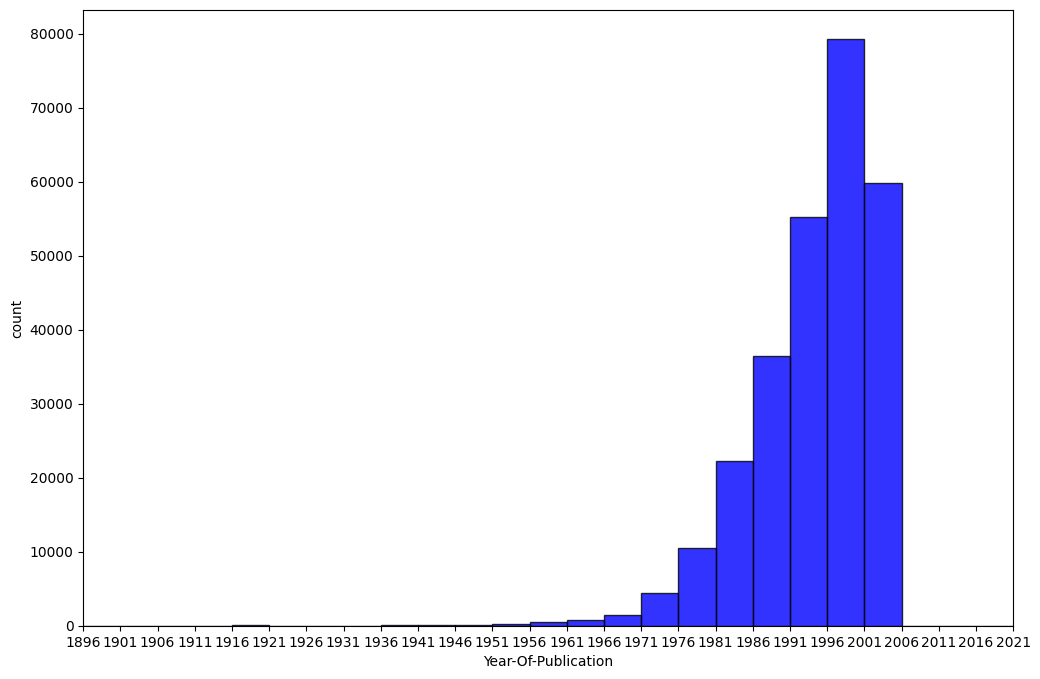

In [ ]:
histogram(
    df_books[df_books["Year-Of-Publication"] > 1900],
    "Year-Of-Publication",
)

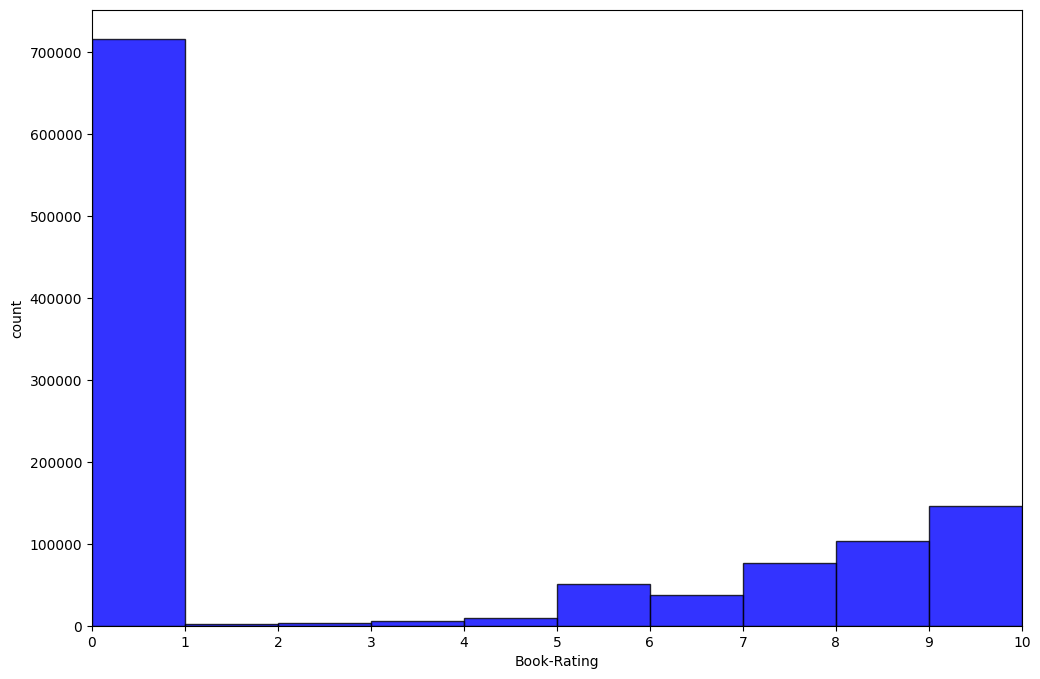

In [ ]:
histogram(df_ratings, "Book-Rating", bins=np.arange(0, 12))

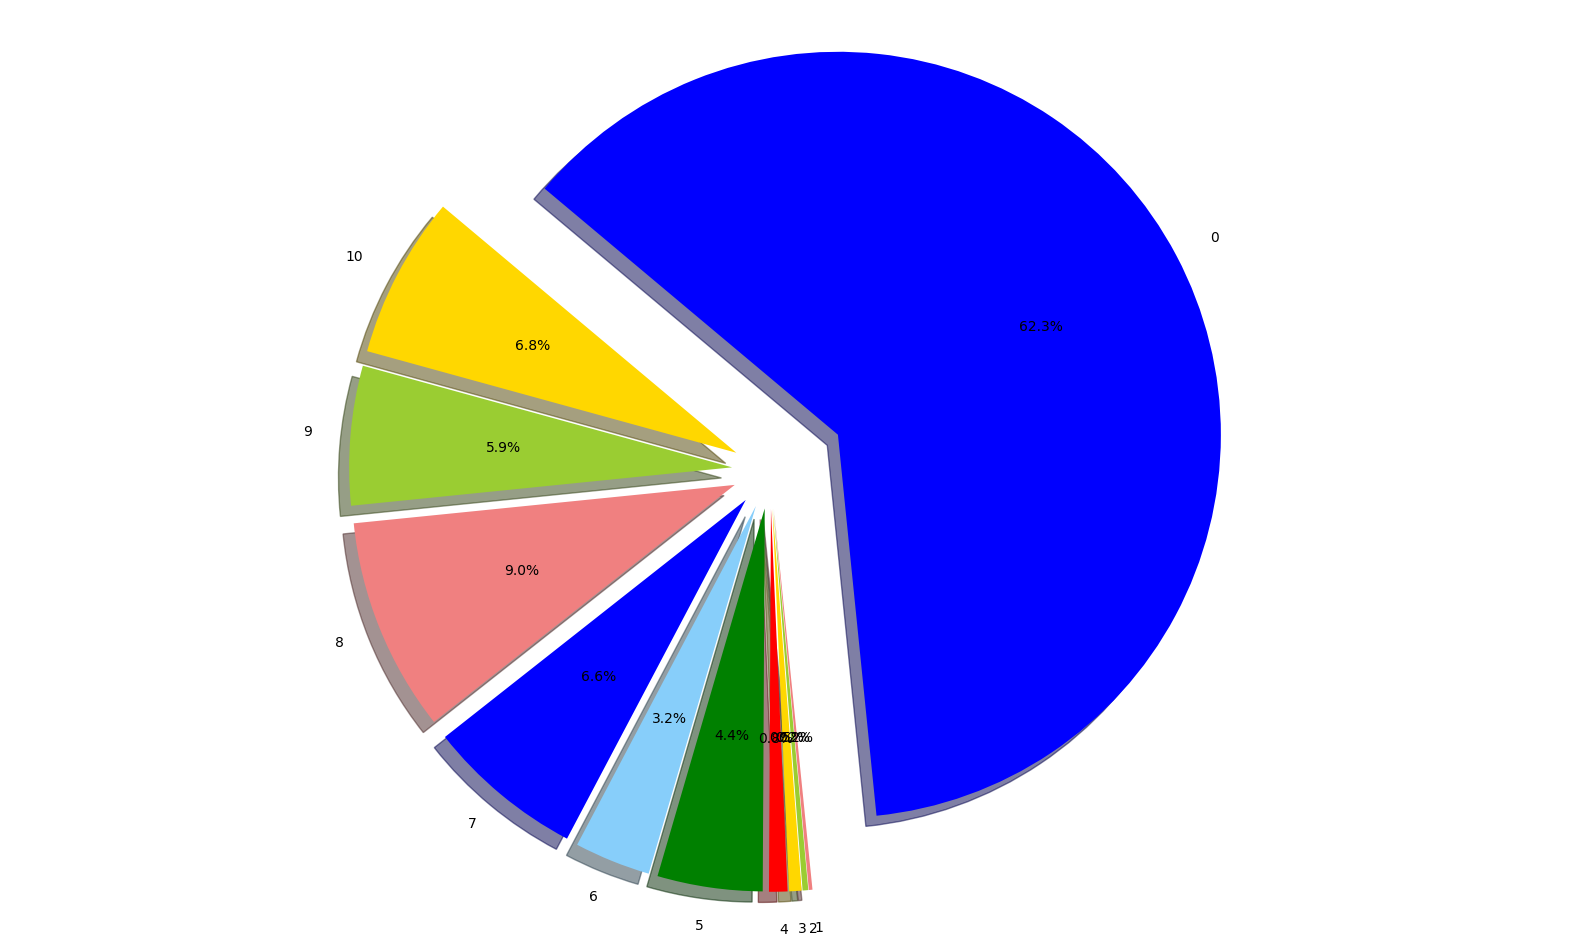

In [ ]:
# create a pie chart of all the ratings (implicit and explicit)
pie_chart(df_ratings, "Book-Rating")

It is clear that most of the ratings in the ratings dataframe is implicit.

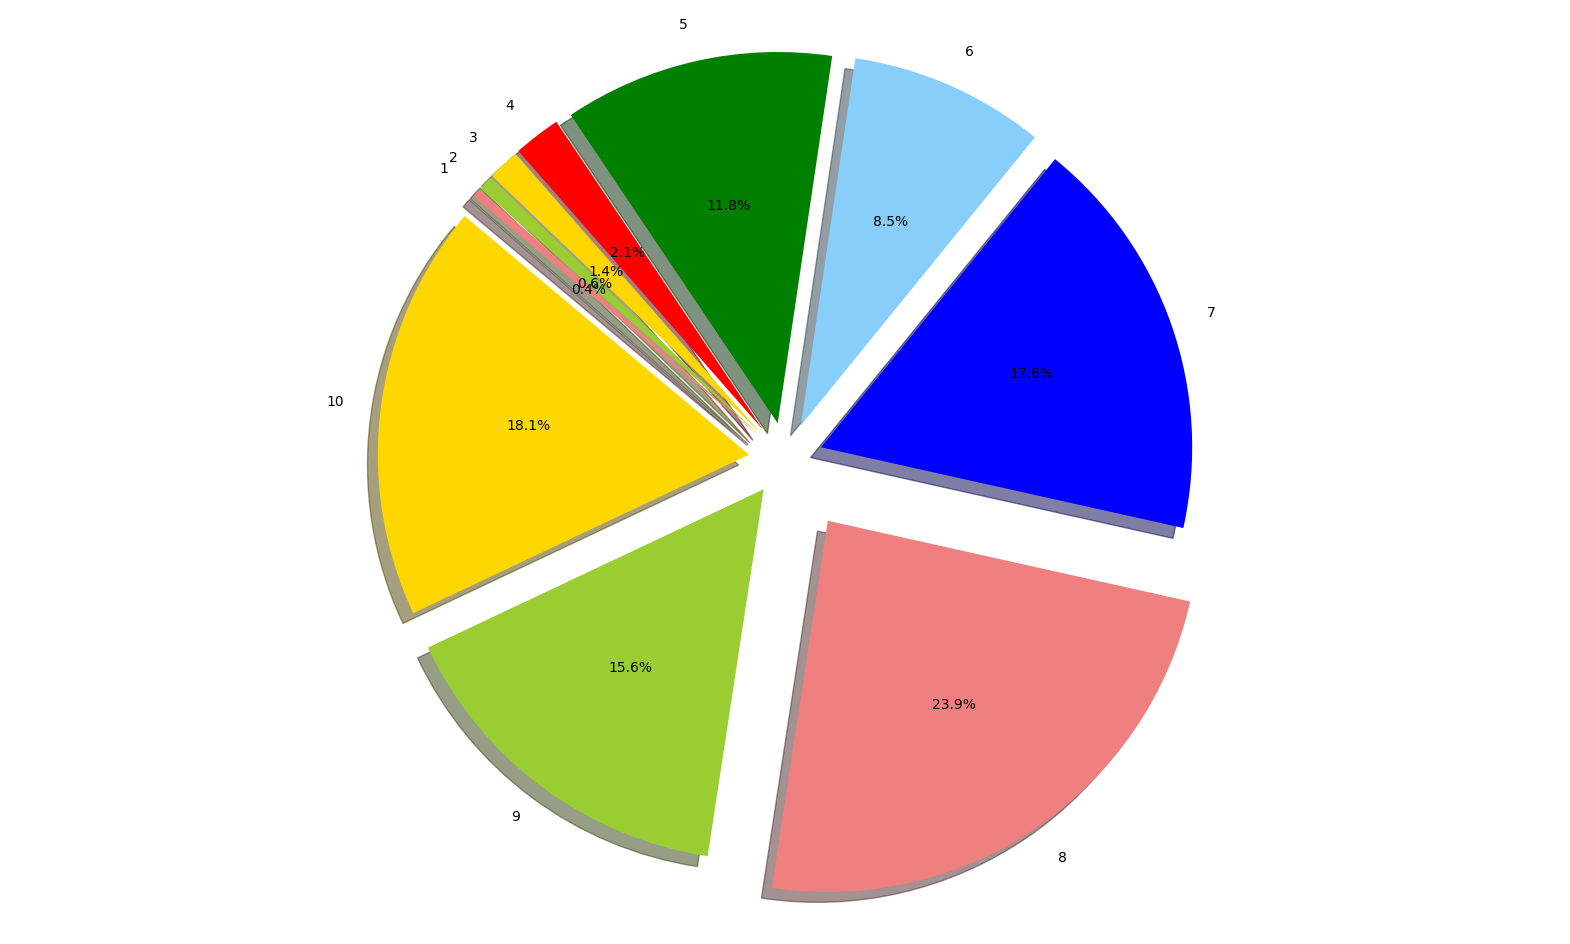

In [ ]:
# create a pie chart of the explicit ratings
pie_chart(df_ratings[df_ratings["Book-Rating"] != 0], "Book-Rating")

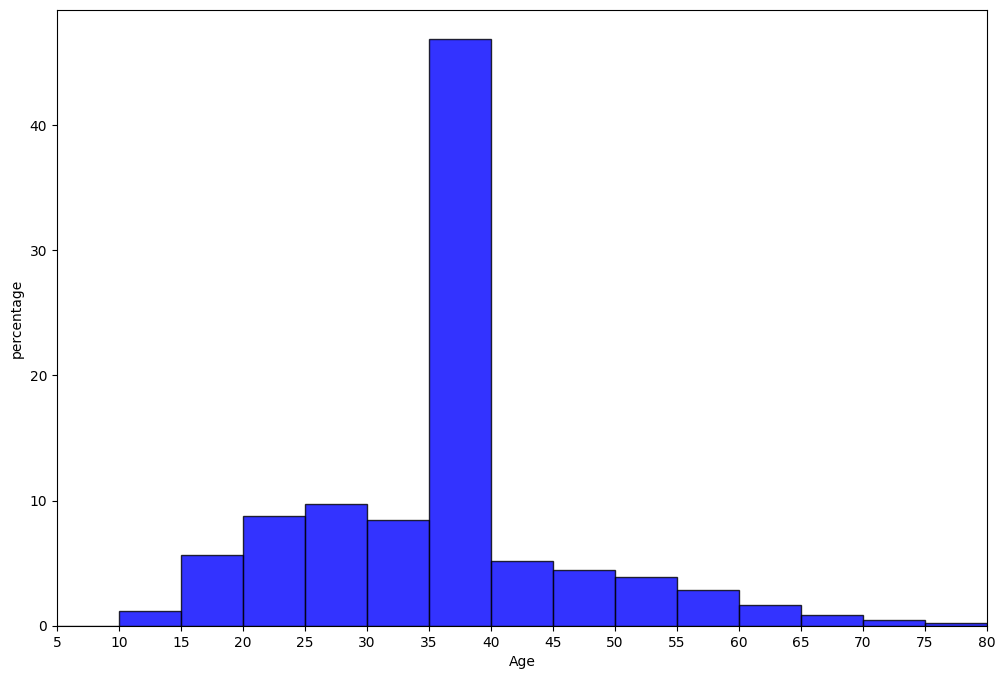

In [ ]:
# create a histogram of Age distribution
histogram(
    df_users,
    "Age",
    use_percentage=True,
)

---

# 5. Recommendation Systems

All three dataset has been cleaned now. In this section, a variety of recommendation systems are tested against this dataset. This section is divided into a
few subsection, in each one a category of these systems are created and evaluated. Most of the available recommendation algorithms are not implemented in the
 pyspark package. As a result, in every situation where I test an algorithm, instead of implementing one from scratch, I go with using the available one in
 the pyspark package.

The whole family of recommender systems is shown in the following picture:
![](src/cat.png)

Among these categories, I will try the following algorithms:
- Popularity based recommender systems
- Collaborative Filtering (Item-based)
    - Memory-based
        - Item-based
    - Model-based
        - Matrix Factorization (ALS)
- Content-based Filtering (IDF and Count Vectorizer)
- Hybrid Approach (Ensemble recommender)

**Popularity based recommendation systems**
The popularity-based recommendation system utilizes the data available on top book rating websites to recommend the most popular books to users based on their
ratings. Although this kind of recommendation system is simple to implement and scalable, it does not provide personalization to the user. Additionally, since the data that this kind of system relies upon is purely based on the ratings provided on the rating websites, it might not reflect user preferences or account regional dialect of every user.


**Association Rule Mining**
Association rule mining (also called as Market Basket Analysis), at a basic level, is a rule-based method that analyzes for patterns of co-occurrences, in a
database(also called Basket Data). It identifies frequent if-then associations called association rules which consists of an antecedent (if) and a consequent
 (then). This method is greatly useful when user choices are not easily accessible. For example, companies that do not have an online presence uses
 association rule mining to study purchase patterns and placing the frequently bought items in the same aisle. Although the analysis is easy to understand
 and interpret, the method can get computationally expensive for large datasets. Since the context of this dataset does not allow for this type of
 algorithms, it will not be evaluated in this project.



As user preferences became easily accessible, recommender systems have been developed to embed user choice and behavior patterns into the algorithms. The other two approaches, content-based filtering and collaborative filtering employs the usage of customer preferences in their algorithms.

**Content-based filtering**
A content-based filtering technique analyzes the past choices of a user and constructs profiles based on the user actions alone to build a preference profile, instead of pairing users with the products that similar users liked.

**Collaborative filtering**
Collaborative filtering systems on the other hand, analyzes interactions or similarity between users and items. Its distinct because it looks at the behavior of multiple customers cross-referencing their purchase histories with each other. Good personalized recommendations enhances the user experience, thereby improving customer satisfaction and loyalty. This technique is generally more accurate than content filtering. This is because this technique analyzes user preferences and uses these for providing personalized recommendations to other similar users.
Collaborative filtering can be further divided into memory-based and model-based collaborative filtering. The memory-based approach uses user rating data to compute similarity between users or items. Memory-based systems are not always as fast and scalable as we would like them to be, especially in the context of actual systems that make real-time recommendations on the basis of large datasets.
Although there are a number of algorithms that can be used to build the model in model-based approach, one of the most popular ones is the Matrix Factorization technique. Matrix factorization achieves collaborative filtering by approximating an incomplete rating matrix using the product of two matrices in a joint latent factor space of dimensionality f. Before we can get into further details of matrix factorization we will describe some key elements of this technique: The rating matrix, latent factors and the latent vectors. A rating matrix is a matrix of u(users) by i(items) of explicit user ratings over items. This is generally sparse because, not all users could have watched all movies. An entry in this sparse matrix corresponds to the rating, given by user u, of an item i. The latent vector of factors are inferred features from movie rating patterns of users, and are estimated by minimizing the loss function. Examples for latent factors in the context of movies, can be genre, depth of a character, amount of action, age group of the target audience or can even be completely uninterpretable. These inferred features are often called latent vectors and the k attributes are often called the latent factors. Furthermore, the expressive power of the model can be tuned by modifying the number of latent factors.

![](src/mat_fact.png)

![](src/col_vs_con.png)

**Hybrid approach**
The hybrid approach of recommender systems use a combination of content-based and collaborative filtering.




In [ ]:
book_name = "Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))"
number_of_recommendations = 10

In [ ]:
# join all the dataframes into a single dataframe
df_all = df_books.join(df_ratings, on="ISBN", how="inner").join(
    df_users,
    on="User-ID",
    how="inner",
)
df_all.show()

+-------+----------+--------------------+--------------------+-------------------+--------------------+-----------+---+-----------+----------------+-----------+
|User-ID|      ISBN|          Book-Title|         Book-Author|Year-Of-Publication|           Publisher|Book-Rating|Age|       City|           State|    Country|
+-------+----------+--------------------+--------------------+-------------------+--------------------+-----------+---+-----------+----------------+-----------+
|     19|0375759778|    Prague : A Novel|     ARTHUR PHILLIPS|               2003|Random House Trad...|          7| 14|     WESTON|           OTHER|     WESTON|
|     22|3442353866|Der Fluch der Kai...|      Eleanor Cooney|               2001|            Goldmann|          0| 35|     ERFURT|      THUERINGEN|     ERFURT|
|     22|3442446937|  Tage der Unschuld.|Richard North Pat...|               2000|            Goldmann|          0| 35|     ERFURT|      THUERINGEN|     ERFURT|
|     22|3404921038|Wie Barney es 

In [ ]:
# separate the dataset based on the explicit and implicit rating. I will be using the explicit dataframe
df_imp = df_all[df_all["Book-Rating"] == 0]
df_exp = df_all[df_all["Book-Rating"] != 0]

In [ ]:
df_exp.count()

383892

In [ ]:
df_exp.columns

['User-ID',
 'ISBN',
 'Book-Title',
 'Book-Author',
 'Year-Of-Publication',
 'Publisher',
 'Book-Rating',
 'Age',
 'City',
 'State',
 'Country']

Some algorithms like **Weighted Average Rating** need the average rating for each book alongside the total number of rating in order to work. So, I will calculate them and add them to the current dataframe.

The formula to of weighted average rating is:
![](src/awr.png)
where:
W = Weighted Rating
R = Average rating for the item
v = Number of ratings for the item
m = Minimum number of ratings required to be in 90 percent percentile.
C = Mean of rating across the whole dataset

In [ ]:
# calculate the average rating for each book
df_exp = (
    df_exp.groupBy("ISBN")
    .agg(F.avg("Book-Rating").alias("avg_book_rating"))
    .withColumn(
        "avg_book_rating",
        F.format_number("avg_book_rating", d=3).alias("avg_book_rating"),
    )
    .withColumn("avg_book_rating", F.col("avg_book_rating").cast(T.FloatType()))
    .join(
        df_exp,
        on="ISBN",
    )
)

# calculate the total number of rating for each book
df_exp = (
    df_exp.groupBy("ISBN")
    .agg(F.count("Book-Rating").alias("total_rating"))
    .join(df_exp, on="ISBN")
)

# calculate average rating for all users
df_exp = (
    df_exp.groupBy("User-ID")
    .agg(F.avg("Book-Rating").alias("avg_user_book_rating"))
    .withColumn(
        "avg_user_book_rating",
        F.format_number("avg_user_book_rating", d=3).alias("avg_user_book_rating"),
    )
    .withColumn(
        "avg_user_book_rating", F.col("avg_user_book_rating").cast(T.FloatType())
    )
    .join(df_exp, on="User-ID")
)

In [ ]:
# calculate the `C` parameter
df_exp.agg(F.mean("avg_book_rating")).show()

+--------------------+
|avg(avg_book_rating)|
+--------------------+
|   7.626764345861918|
+--------------------+



In [ ]:
# calculate the `m` parameter
df_exp.stat.approxQuantile("total_rating", [0.9], 0.01)

[61.0]

In [ ]:
## C - Mean vote across the whole
C = 7.63

## Minimum number of ratings required to be in the chart
m = 59.0

In [ ]:
# calculate the war score based on the given formula
df_exp = (
    df_exp.withColumn(
        "war_score",
        ((F.col("avg_book_rating") * F.col("total_rating")) + (C * m))
        / (F.col("total_rating") + m),
    )
    .withColumn("war_score", F.format_number("war_score", 3))
    .withColumn("war_score", F.col("war_score").cast(T.FloatType()))
)

In [ ]:
df_exp.printSchema()

root
 |-- User-ID: long (nullable = true)
 |-- avg_user_book_rating: float (nullable = true)
 |-- ISBN: string (nullable = true)
 |-- total_rating: long (nullable = false)
 |-- avg_book_rating: float (nullable = true)
 |-- Book-Title: string (nullable = true)
 |-- Book-Author: string (nullable = true)
 |-- Year-Of-Publication: integer (nullable = true)
 |-- Publisher: string (nullable = true)
 |-- Book-Rating: long (nullable = true)
 |-- Age: integer (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- war_score: float (nullable = true)



In [ ]:
df_exp.show(5, vertical=False)

+-------+--------------------+----------+------------+---------------+--------------------+--------------+-------------------+--------------------+-----------+---+-------------+----------+-------------+---------+
|User-ID|avg_user_book_rating|      ISBN|total_rating|avg_book_rating|          Book-Title|   Book-Author|Year-Of-Publication|           Publisher|Book-Rating|Age|         City|     State|      Country|war_score|
+-------+--------------------+----------+------------+---------------+--------------------+--------------+-------------------+--------------------+-----------+---+-------------+----------+-------------+---------+
|  36103|               7.571|006019541X|           5|            7.2|          Blue Angel|Francine Prose|               2000|HarperCollins Pub...|          8| 35|      CHICAGO|  ILLINOIS|      CHICAGO|    7.596|
| 160434|               8.481|0060965827|           1|            6.0|The Simpsons Unce...| Matt Groening|               1991|  Perennial Currents| 

In [ ]:
_cols = (
    "ISBN",
    "Book-Title",
    "Book-Author",
    "Book-Rating",
    "Year-Of-Publication",
    "Publisher",
    "total_rating",
    "avg_book_rating",
    "avg_user_book_rating",
    "war_score",
)

## 5.1 Popularity Based (Top in the whole collection)

In [ ]:
def rec_popularity_based(
    df_in: pyspark.sql.DataFrame,
    num: int = 10,
):
    """
    Recommend most popular books in the dataframe.

    Parameters
    ----------
    df_in : pyspark.sql.DataFrame
        Dataframe to use for generating the recommendation.
    num : int
        Number of recommendation to calculate.
    """
    df_in.select(*_cols).dropDuplicates(["ISBN"]).sort(
        "total_rating",
        ascending=False,
    ).show(num, truncate=50)

In [ ]:
rec_popularity_based(df_exp)

+----------+--------------------------------------------------+---------------+-----------+-------------------+-----------------------+------------+---------------+--------------------+---------+
|      ISBN|                                        Book-Title|    Book-Author|Book-Rating|Year-Of-Publication|              Publisher|total_rating|avg_book_rating|avg_user_book_rating|war_score|
+----------+--------------------------------------------------+---------------+-----------+-------------------+-----------------------+------------+---------------+--------------------+---------+
|0316666343|                         The Lovely Bones: A Novel|   Alice Sebold|         10|               2002|          Little, Brown|         707|          8.185|               7.958|    8.142|
|0971880107|                                       Wild Animus|   Rich Shapero|          7|               2004|                Too Far|         581|          4.391|                 7.0|     4.69|
|0385504209|        

## 5.2 Popularity Based (Top in a given place)

In [ ]:
def filter_by_place(
    df_in: pyspark.sql.DataFrame,
    place: str,
    type_: str = "country",  # values are "country", "state", "city"
) -> pyspark.sql.DataFrame:
    """
    Filter the dataframe by the given place.

    Parameters
    ----------
    df_in : pyspark.sql.DataFrame
        Dataframe to filter.
    place : str
        Name of the place to filter the dataframe by.
    type_ : str, default : "country"
        Type of the place to filter.

    Returns
    -------
    pyspark.sql.DataFrame
        The filtered dataframe by the given place.

    """
    if not df_in or not place:
        raise ValueError("Invalid dataframe or place !")

    if type_ not in ("country", "state", "city"):
        raise ValueError("Invalid place type!")

    place = place.upper()
    if type_ == "city":
        return df_in[df_in["City"] == place]
    elif type_ == "state":
        return df_in[df_in["State"] == place]
    elif type_ == "country":
        return df_in[df_in["Country"] == place]

def rec_popularity_based_by_place(
    df_in: pyspark.sql.DataFrame,
    place: str,
    type_: str = "country",
    num: int = 10,
):
    """
    Recommend the most popular items by a given place.

    Parameters
    ----------
    df_in : pyspark.sql.DataFrame
        Dataframe to filter.
    place : str
        Name of the place.
    type_ : str, default : "country"
        Type of the place to filter.
    num : int, default : 10
        Number of recommendation to give.
    """
    df_filtered_by_place = filter_by_place(df_in, place, type_=type_)
    rec_popularity_based(df_in=df_filtered_by_place, num=num)

In [ ]:
rec_popularity_based_by_place(df_exp, "ny", type_="state")

+----------+--------------------------------------------------+----------------------+-----------+-------------------+---------------------+------------+---------------+--------------------+---------+
|      ISBN|                                        Book-Title|           Book-Author|Book-Rating|Year-Of-Publication|            Publisher|total_rating|avg_book_rating|avg_user_book_rating|war_score|
+----------+--------------------------------------------------+----------------------+-----------+-------------------+---------------------+------------+---------------+--------------------+---------+
|1558743669|A Child Called \It\": One Child's Courage to Su...|           Dave Pelzer|          8|               1995|Health Communications|         134|            8.0|               6.556|    7.887|
|0684874350|                                    ANGELA'S ASHES|         Frank McCourt|          8|               1996|             Scribner|         132|          8.386|               6.556|    8.

In [ ]:
rec_popularity_based_by_place(df_exp, "ny", type_="city")

+----------+--------------------------------------------------+----------------------+-----------+-------------------+-----------------------+------------+---------------+--------------------+---------+
|      ISBN|                                        Book-Title|           Book-Author|Book-Rating|Year-Of-Publication|              Publisher|total_rating|avg_book_rating|avg_user_book_rating|war_score|
+----------+--------------------------------------------------+----------------------+-----------+-------------------+-----------------------+------------+---------------+--------------------+---------+
|0385504209|                                 The Da Vinci Code|             Dan Brown|         10|               2003|              Doubleday|         487|          8.435|                 8.0|    8.348|
|044023722X|                                   A Painted House|          John Grisham|          6|               2001|Dell Publishing Company|         282|           7.34|                 

In [ ]:
rec_popularity_based_by_place(df_exp, "usa", type_="country")

+----------+------------+-----------------+-----------+-------------------+---------+------------+---------------+--------------------+---------+
|      ISBN|  Book-Title|      Book-Author|Book-Rating|Year-Of-Publication|Publisher|total_rating|avg_book_rating|avg_user_book_rating|war_score|
+----------+------------+-----------------+-----------+-------------------+---------+------------+---------------+--------------------+---------+
|1551667894|Four Seasons|Mary Alice Monroe|          8|               2001|     Mira|          11|          8.455|                 8.0|     7.76|
+----------+------------+-----------------+-----------+-------------------+---------+------------+---------------+--------------------+---------+



In [ ]:
rec_popularity_based_by_place(df_exp, "italy", type_="country")

+----------+-------------+----------------------------+-----------+-------------------+-----------+------------+---------------+--------------------+---------+
|      ISBN|   Book-Title|                 Book-Author|Book-Rating|Year-Of-Publication|  Publisher|total_rating|avg_book_rating|avg_user_book_rating|war_score|
+----------+-------------+----------------------------+-----------+-------------------+-----------+------------+---------------+--------------------+---------+
|880781028X|Il Gattopardo|Guiseppe Tomasi di Lampedusa|         10|               1995|Feltrinelli|           3|          9.333|                10.0|    7.712|
+----------+-------------+----------------------------+-----------+-------------------+-----------+------------+---------------+--------------------+---------+



In [ ]:
rec_popularity_based_by_place(df_exp, "Chicago", type_="city")

+----------+--------------------------------------------------+---------------+-----------+-------------------+-----------------------+------------+---------------+--------------------+---------+
|      ISBN|                                        Book-Title|    Book-Author|Book-Rating|Year-Of-Publication|              Publisher|total_rating|avg_book_rating|avg_user_book_rating|war_score|
+----------+--------------------------------------------------+---------------+-----------+-------------------+-----------------------+------------+---------------+--------------------+---------+
|0316666343|                         The Lovely Bones: A Novel|   Alice Sebold|         10|               2002|          Little, Brown|         707|          8.185|                10.0|    8.142|
|0971880107|                                       Wild Animus|   Rich Shapero|          2|               2004|                Too Far|         581|          4.391|               6.939|     4.69|
|0385504209|        

In [ ]:
rec_popularity_based_by_place(df_exp, "london", type_="city")

+----------+--------------------------------------------------+---------------+-----------+-------------------+-----------------------+------------+---------------+--------------------+---------+
|      ISBN|                                        Book-Title|    Book-Author|Book-Rating|Year-Of-Publication|              Publisher|total_rating|avg_book_rating|avg_user_book_rating|war_score|
+----------+--------------------------------------------------+---------------+-----------+-------------------+-----------------------+------------+---------------+--------------------+---------+
|0316666343|                         The Lovely Bones: A Novel|   Alice Sebold|          9|               2002|          Little, Brown|         707|          8.185|                 7.0|    8.142|
|0971880107|                                       Wild Animus|   Rich Shapero|          3|               2004|                Too Far|         581|          4.391|                 3.0|     4.69|
|0385504209|        

## 5.3 Popularity Based (Books by the same author, publisher)

In [ ]:
def filter_by_author(
    df_in: pyspark.sql.DataFrame,
    author: str,
) -> pyspark.sql.DataFrame:
    """
    Filter the dataframe by the given author.

    Parameters
    ----------
    df_in : pyspark.sql.DataFrame
        Dataframe to filter.
    author : str
        Name of the author.

    Returns
    -------
    pyspark.sql.DataFrame
        Filtered dataframe by the given author name.

    """
    if not df_in or not author:
        raise ValueError("Invalid dataframe or author name !")

    if df_in[df_in["Book-Author"] == author].count():
        return df_in[df_in["Book-Author"] == author]
    else:
        raise ValueError("Invalid author name!")


def filter_by_publisher(
    df_in: pyspark.sql.DataFrame,
    publisher: str,
):
    """
    Filter the dataframe by the given author.

    Parameters
    ----------
    df_in : pyspark.sql.DataFrame
        Dataframe to filter.
    publisher : str
        Name of the publisher.

    Returns
    -------
    pyspark.sql.DataFrame
        Filtered dataframe by the given publisher name.

    """
    if not df_in or not publisher:
        raise ValueError("Invalid dataframe or publisher name !")

    if df_in[df_in["Publisher"] == publisher].count():
        return df_in[df_in["Publisher"] == publisher]
    else:
        raise ValueError("Invalid publisher name!")


def rec_popularity_based_by_author(
    df_in: pyspark.sql.DataFrame,
    author: str,
    num: int = 10,
) -> None:
    """
    Recommend popular books based on an author's name.

    Parameters
    ----------
    df_in : pyspark.sql.DataFrame
        Dataframe to query.
    author : str
        Name of the author.
    num : int, default : 10
        Number of recommendations to give.
    """
    df_filtered_by_author = filter_by_author(df_in, author)
    rec_popularity_based(df_filtered_by_author, num=num)


def rec_popularity_based_by_publisher(
    df_in: pyspark.sql.DataFrame,
    publisher: str,
    num: int = 10,
):
    """
    Recommend popular books based on an author's name.

    Parameters
    ----------
    df_in : pyspark.sql.DataFrame
        Dataframe to query.
    publisher : str
        Name of the publisher.
    num : int, default : 10
        Number of recommendations to give.
    """
    df_filtered_by_publisher = filter_by_publisher(df_in, publisher)
    rec_popularity_based(df_filtered_by_publisher, num=num)

In [ ]:
rec_popularity_based_by_author(df_exp, "Paul Vincent")

+----------+---------------+------------+-----------+-------------------+----------------------+------------+---------------+--------------------+---------+
|      ISBN|     Book-Title| Book-Author|Book-Rating|Year-Of-Publication|             Publisher|total_rating|avg_book_rating|avg_user_book_rating|war_score|
+----------+---------------+------------+-----------+-------------------+----------------------+------------+---------------+--------------------+---------+
|1844262553|           Free|Paul Vincent|          8|               2003|    Upfront Publishing|          50|            8.6|                 8.0|    8.075|
|1903970601|The Death of Me|Paul Vincent|          7|               2002|Central Publishing Ltd|           1|            7.0|                 7.0|     7.62|
+----------+---------------+------------+-----------+-------------------+----------------------+------------+---------------+--------------------+---------+



In [ ]:
rec_popularity_based_by_publisher(df_exp, "Warner Books")

+----------+--------------------------------------------------+-------------------+-----------+-------------------+------------+------------+---------------+--------------------+---------+
|      ISBN|                                        Book-Title|        Book-Author|Book-Rating|Year-Of-Publication|   Publisher|total_rating|avg_book_rating|avg_user_book_rating|war_score|
+----------+--------------------------------------------------+-------------------+-----------+-------------------+------------+------------+---------------+--------------------+---------+
|0446672211|Where the Heart Is (Oprah's Book Club (Paperback))|       Billie Letts|         10|               1998|Warner Books|         295|          8.142|               7.733|    8.057|
|0446605239|                                      The Notebook|    Nicholas Sparks|          5|               1998|Warner Books|         206|          7.689|                 5.0|    7.676|
|044651652X|                     The Bridges of Madison

## 5.4 Popularity Based (Yearly)

In [ ]:
def filter_by_year(
    df_in: pyspark.sql.DataFrame,
    year: int,
) -> pyspark.sql.DataFrame:
    """
    Filter the dataframe by the given year.

    Parameters
    ----------
    df_in : pyspark.sql.DataFrame
        Dataframe to query.
    year : int
        Year to filter the dataframe by.

    Returns
    -------
    pyspark.sql.DataFrame
        Filtered dataframe by the given year.

    """
    if not df_in or not year:
        raise ValueError("Invalid dataframe or year!")

    if df_in[df_in["Year-Of-Publication"] == year].count():
        return df_in[df_in["Year-Of-Publication"] == year]
    else:
        raise ValueError("Invalid year!")


def rec_popularity_based_by_year(
    df_in: pyspark.sql.DataFrame,
    year: int,
    num: int = 10,
) -> None:
    """
    Recommend popular books based of a Year.

    Parameters
    ----------
    df_in : pyspark.sql.DataFrame
        Dataframe to query.
    year : int
        Year to recommend the books for.
    num : int, default : 10
        Number of recommendations to give.
    """
    df_filtered_by_year = filter_by_year(df_in, year)
    rec_popularity_based(df_filtered_by_year, num=num)

In [ ]:
rec_popularity_based_by_year(df_exp, 2003)

+----------+--------------------------------------------------+----------------------+-----------+-------------------+--------------------+------------+---------------+--------------------+---------+
|      ISBN|                                        Book-Title|           Book-Author|Book-Rating|Year-Of-Publication|           Publisher|total_rating|avg_book_rating|avg_user_book_rating|war_score|
+----------+--------------------------------------------------+----------------------+-----------+-------------------+--------------------+------------+---------------+--------------------+---------+
|0385504209|                                 The Da Vinci Code|             Dan Brown|          9|               2003|           Doubleday|         487|          8.435|               7.962|    8.348|
|0142001740|                           The Secret Life of Bees|         Sue Monk Kidd|          8|               2003|       Penguin Books|         307|          8.453|                 7.5|     8.32|


In [ ]:
rec_popularity_based_by_year(df_exp, 1994)

+----------+--------------------------------------------------+--------------------+-----------+-------------------+-----------------------+------------+---------------+--------------------+---------+
|      ISBN|                                        Book-Title|         Book-Author|Book-Rating|Year-Of-Publication|              Publisher|total_rating|avg_book_rating|avg_user_book_rating|war_score|
+----------+--------------------------------------------------+--------------------+-----------+-------------------+-----------------------+------------+---------------+--------------------+---------+
|0804106304|                                 The Joy Luck Club|             Amy Tan|          6|               1994|   Prentice Hall (K-12)|         194|          8.196|               7.136|    8.064|
|0671510053|                                     SHIPPING NEWS|        Annie Proulx|          5|               1994|               Scribner|         150|          7.733|               7.382|    7.

## 5.5 Popularity Based (Weighted Average Rating)

In [ ]:
def rec_weighted_average_rating(
    df_in: pyspark.sql.DataFrame,
    num: int = 10,
) -> None:
    """
    Recommend popular books by weighted average rating score.

    Parameters
    ----------
    df_in : pyspark.sql.DataFrame
        Dataframe to query.
    num : int, default : 10
        Number of recommendations to give.
    """
    df_in.select(*_cols).dropDuplicates(["ISBN"]).sort(
        "war_score",
        ascending=False,
    ).show(num, truncate=50)

In [ ]:
rec_weighted_average_rating(df_exp, 10)

+----------+--------------------------------------------------+--------------+-----------+-------------------+--------------------------+------------+---------------+--------------------+---------+
|      ISBN|                                        Book-Title|   Book-Author|Book-Rating|Year-Of-Publication|                 Publisher|total_rating|avg_book_rating|avg_user_book_rating|war_score|
+----------+--------------------------------------------------+--------------+-----------+-------------------+--------------------------+------------+---------------+--------------------+---------+
|0439139597|      Harry Potter and the Goblet of Fire (Book 4)| J. K. Rowling|          8|               2000|                Scholastic|         137|          9.263|               8.481|    8.771|
|059035342X|Harry Potter and the Sorcerer's Stone (Harry Po...| J. K. Rowling|         10|               1999|    Arthur A. Levine Books|         315|          8.937|               8.571|    8.731|
|043935806

## 5.6 Collaborative Filtering (ALS: Alternating Least Square)

Alternating Least Squares (ALS) is an iterative optimization algorithm commonly used in collaborative filtering and matrix factorization problems. It is
particularly effective in the context of recommender systems for predicting user preferences or making personalized recommendations. The goal of ALS is to
factorize a large matrix, typically a user-item matrix, into two smaller matrices such that their product approximates the original matrix. By doing so, ALS aims to capture latent factors or features that explain the observed ratings or interactions between users and items. ALS is often used in scenarios where the user-item matrix is sparse, meaning that not all users have rated or interacted with all items. By factorizing the matrix into lower-dimensional latent factors, ALS can effectively handle missing values and provide personalized recommendations based on the patterns and similarities it discovers.

There are other ways to do matrix factorization, but they are not natively supported by pyspark package.

In [ ]:
# print out the total number of explicit ratings
df_exp.count()

383892

In [ ]:
# show the histogram of unique book total ratings
histogram(df_exp.dropDuplicates(["ISBN"]), "total_rating", fig_size=general_fig_size)

In [ ]:
# show the histogram of unique book total ratings above 30
histogram(
    df_exp.dropDuplicates(["ISBN"]).where(F.col("total_rating") > 30),
    "total_rating",
    fig_size=general_fig_size,
)

In [ ]:
# show the histogram of unique book total ratings above 40
histogram(
    df_exp.dropDuplicates(["ISBN"]).where(F.col("total_rating") > 40),
    "total_rating",
    fig_size=general_fig_size,
)

In [ ]:
# show the histogram of unique book total ratings above 50
histogram(
    df_exp.dropDuplicates(["ISBN"]).where(F.col("total_rating") > 50),
    "total_rating",
    fig_size=general_fig_size,
)

Since the number of total number of ratings are on the lower end of the histogram, it only complicates the calculation process of the ALS and won't give much
 information based on the low number of ratings. As a result, I choose to train the ALS model on the portion of the dataframe that has `total_rating` above
 **40**. The choice is optional and depends on the kind of available hardware.

In [ ]:
# filter the dataframe by ratings of books that have `total_rating` above 40
data = df_exp[df_exp["total_rating"] > 40].select("ISBN", "User-ID", "Book-Rating")

# print out the top-10 entries
data.show(10)

+----------+-------+-----------+
|      ISBN|User-ID|Book-Rating|
+----------+-------+-----------+
|0060976845|  10959|          9|
|0312980140| 103496|          5|
|034540288X| 222204|          9|
|0380813815| 118628|          8|
|0380813815| 265000|         10|
|043935806X|  35148|         10|
|043935806X|  74185|         10|
|043935806X| 199209|          9|
|0451156609|  50221|          7|
|0767905385|  61888|          9|
+----------+-------+-----------+
only showing top 10 rows



In [ ]:
# ALS model needs the user-item inputs to be numeric and ISBN can not cast into integer without running into a bunch of problems.
# The easiest way is to hash the ISBN which will cast it into integers without any problems.
data = data.withColumn("ISBN", F.hash("ISBN"))

data.show(10)

+-----------+-------+-----------+
|       ISBN|User-ID|Book-Rating|
+-----------+-------+-----------+
|-2040463592|  10959|          9|
| -714613190| 103496|          5|
| 2021791201| 222204|          9|
|-2055838995| 118628|          8|
|-2055838995| 265000|         10|
|  728763404|  35148|         10|
|  728763404|  74185|         10|
|  728763404| 199209|          9|
|-1024403799|  50221|          7|
| 1004800200|  61888|          9|
+-----------+-------+-----------+
only showing top 10 rows



In [ ]:
# print out the schema of the data
data.printSchema()

root
 |-- ISBN: integer (nullable = false)
 |-- User-ID: long (nullable = true)
 |-- Book-Rating: long (nullable = true)



The User-Item columns are in numeric format now.

In [ ]:
# Dividing the data using random split into train_data and test_data in 80% and 20% respectively
train_data, test_data = data.randomSplit([0.8, 0.2])

In [ ]:
# Build the recommendation model using ALS on the training data
als = ALS(
    maxIter=5,
    regParam=0.01,
    userCol="User-ID",
    itemCol="ISBN",
    ratingCol="Book-Rating",
    nonnegative=True,
    coldStartStrategy="drop",
    implicitPrefs=False,
)

# Fit the model on the train_data
model = als.fit(train_data)

- **numBlocks** is the number of blocks the users and items will be partitioned into in order to parallelize computation (defaults to 10).
- **rank** is the number of latent factors in the model (defaults to 10).
- **maxIter** is the maximum number of iterations to run (defaults to 10).
- **regParam** specifies the regularization parameter in ALS (defaults to 1.0).
- **implicitPrefs** specifies whether to use the explicit feedback ALS variant or one adapted for implicit feedback data (defaults to false which means using
explicit feedback).
- **alpha** is a parameter applicable to the implicit feedback variant of ALS that governs the baseline confidence in preference observations (defaults to 1.0).
- **nonnegative** specifies whether or not to use nonnegative constraints for least squares (defaults to false).

**Cold-start strategy**:
When making predictions using an ALSModel, it is common to encounter users and/or items in the test dataset that were not present during training the model. This typically occurs in two scenarios:
1. In production, for new users or items that have no rating history and on which the model has not been trained (this is the “cold start problem”).
2. During cross-validation, the data is split between training and evaluation sets. When using simple random splits as in Spark’s CrossValidator or
TrainValidationSplit, it is actually very common to encounter users and/or items in the evaluation set that are not in the training set.

By default, Spark assigns NaN predictions during ALSModel.transform when a user and/or item factor is not present in the model. This can be useful in a production system, since it indicates a new user or item, and so the system can make a decision on some fallback to use as the prediction.

However, this is undesirable during cross-validation, since any NaN predicted values will result in NaN results for the evaluation metric (for example when using RegressionEvaluator). This makes model selection impossible.

However, this is undesirable during cross-validation, since any NaN predicted values will result in NaN results for the evaluation metric (for example when using RegressionEvaluator). This makes model selection impossible.



In [ ]:
# Evaluate the model by computing the RMSE on the test data
predictions = model.transform(test_data)

# Display predictions calculated by the model
predictions.show(10)

+-----------+-------+-----------+----------+
|       ISBN|User-ID|Book-Rating|prediction|
+-----------+-------+-----------+----------+
|-2140640191|  12289|          8| 4.6322236|
|-2140640191|  33319|          7|  8.044215|
|-2140640191|  64429|          7| 3.7961462|
|-2140640191|  80820|          9|  2.939379|
|-2140640191|  97754|          5|  4.815014|
|-2140640191| 122793|          9|  8.099711|
|-2140640191| 136139|          8| 5.7244744|
|-2140640191| 141109|          8|  3.879033|
|-2140640191| 153054|          8|  6.618154|
|-2140640191| 197775|          9|  7.060942|
+-----------+-------+-----------+----------+
only showing top 10 rows



In [ ]:
# calculate RMSE
evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="Book-Rating",
    predictionCol="prediction",
)
rmse = evaluator.evaluate(predictions)

print("Root-mean-square error = " + str(rmse))

Root-mean-square error = 4.059742680067721


In [ ]:
# Generate top 10 book recommendations for each user
user_recs = model.recommendForAllUsers(10)
user_recs.count()

19736

In [ ]:
user_recs.show(10, truncate=True)

+-------+--------------------+
|User-ID|     recommendations|
+-------+--------------------+
|    243|[{1273400508, 22....|
|    496|[{295965444, 11.1...|
|   1025|[{1273400508, 21....|
|   1650|[{-234141204, 20....|
|   1718|[{-250671572, 16....|
|   1903|[{732132027, 16.4...|
|   2559|[{1443464530, 14....|
|   2776|[{1273400508, 12....|
|   2996|[{1273400508, 20....|
|   3601|[{-870121945, 17....|
+-------+--------------------+
only showing top 10 rows



In [ ]:
# Filtering user with user id "36609"
user1 = test_data.filter(test_data["User-ID"] == 36609).select(
    ["ISBN", "User-ID", "Book-Rating"]
)

# Displaying user1 data
user1.show()

+-----------+-------+-----------+
|       ISBN|User-ID|Book-Rating|
+-----------+-------+-----------+
|-2055838995|  36609|          8|
| 1491391103|  36609|          9|
+-----------+-------+-----------+



In [ ]:
# Training and evaluating for user1 with our model trained with the help of training data
recommendations = model.transform(user1)

# Displaying the predictions of books for user1
recommendations.orderBy("prediction", ascending=False).show()

+-----------+-------+-----------+----------+
|       ISBN|User-ID|Book-Rating|prediction|
+-----------+-------+-----------+----------+
|-2055838995|  36609|          8| 17.794107|
| 1491391103|  36609|          9| 11.242384|
+-----------+-------+-----------+----------+



In [ ]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# Add hyperparameters and their respective values to param_grid
param_grid = (
    ParamGridBuilder()
    .addGrid(als.rank, [10, 50, 100])
    .addGrid(als.maxIter, [5, 20])
    .addGrid(als.regParam, [0.01, 0.05, 0.1])
    .build()
)

crossval = CrossValidator(
    estimator=als,
    estimatorParamMaps=param_grid,
    evaluator=RegressionEvaluator(
        metricName="rmse",
        labelCol="Book-Rating",
        predictionCol="prediction",
    ),
    numFolds=2,
)

# Run cross-validation, and choose the best set of parameters.
cvModel = crossval.fit(train_data)
predictions = cvModel.transform(test_data)

]

In [ ]:
predictions.show(10)

+-----------+-------+-----------+----------+
|       ISBN|User-ID|Book-Rating|prediction|
+-----------+-------+-----------+----------+
|-2140640191|  12289|          8|   5.65832|
|-2140640191|  33319|          7|  7.707922|
|-2140640191|  64429|          7|   7.93621|
|-2140640191|  80820|          9|  5.318281|
|-2140640191|  97754|          5| 5.6075244|
|-2140640191| 122793|          9|    8.3343|
|-2140640191| 136139|          8| 7.9246283|
|-2140640191| 141109|          8| 3.7973566|
|-2140640191| 153054|          8|  8.854836|
|-2140640191| 197775|          9|  8.012926|
+-----------+-------+-----------+----------+
only showing top 10 rows



In [ ]:
# calculate RMSE
evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="Book-Rating",
    predictionCol="prediction",
)
rmse = evaluator.evaluate(predictions)

print("Root-mean-square error = " + str(rmse))

Root-mean-square error = 1.9233225058906318


## 5.7 Collaborative Based Recommendation (Item-Based Filtering)
Item-based filtering, a variant of collaborative filtering, focuses on the similarities between items rather than users. It leverages the notion that items
with similar characteristics or attributes tend to be preferred by users in a similar manner. One common method used in item-based filtering is cosine
similarity. To generate recommendations for a user, item-based filtering aggregates the preferences or ratings of similar items. This is typically done by
taking a weighted average of the ratings of similar items, where the weights are determined by the item similarities. Item-based filtering using cosine
similarity has several advantages. It is computationally efficient since the item similarity matrix can be precomputed offline and reused for multiple
recommendation requests. It also handles the cold-start problem, where new items without sufficient ratings can still be recommended based on their similarities to existing items. However, item-based filtering may face challenges in scenarios with a large number of items since calculating pairwise similarities for all items can be computationally expensive. Additionally, it may not capture some nuanced user preferences or trends as it focuses solely on item similarities. Despite these limitations, item-based filtering using cosine similarity remains a popular and effective approach for generating personalized recommendations in many recommender systems.

Since the similarity function are not natively supported by pyspark, I reimplemented the methods using available functions in the pyspark. It is not as fast
as the native methods, but it will do just fine for this project.

The predicted rating for a book by user for all the algorithms is calculated by the following formula:
![](src/predicted_rating.png)

In [ ]:
SIMILARITY_METHODS = ["adjusted_cosine", "pearson", "cosine"]

def compute_similarity(user_book_ratings):
    other_books = user_book_ratings.select(
        F.col("user").alias("user_other"),
        F.col("book").alias("book_other"),
        F.col("rating").alias("rating_other"),
    )

    # cosine similarity numerator
    # \sum_i A_i*B_i
    numerator = (
        user_book_ratings.join(
            other_books, on=F.col("user") == F.col("user_other"), how="inner"
        )
        .filter(F.col("book") != F.col("book_other"))
        .groupby(["book", "book_other"])
        .agg(F.sum(F.col("rating_other") * F.col("rating")).alias("cum_prod"))
        .select(
            F.col("book").alias("book_n"),
            F.col("book_other").alias("book_other_n"),
            F.col("cum_prod"),
        )
    )

    # book, book_other pairs for which numerator is not 0
    numerator_books = numerator.select(["book_n", "book_other_n"])

    # compute the norms for all books
    # (\sum_i A_i^2)^{1/2}
    norms = (
        user_book_ratings.groupby("book")
        .agg(F.sqrt(F.sum(F.col("rating") * F.col("rating"))).alias("norm"))
        .select(F.col("book").alias("book_d"), F.col("norm"))
    )

    # create other norms df
    norms_other = norms.select(
        F.col("book_d").alias("book_other_d"), F.col("norm").alias("norm_other")
    )

    # compute cosine similarity denominator
    # (\sum_i A_i^2)^{1/2} * (\sum_i B_i^2)^{1/2}
    denominator = (
        numerator_books.join(norms, on=F.col("book_d") == F.col("book_n"), how="inner")
        .join(
            norms_other, on=F.col("book_other_d") == F.col("book_other_n"), how="inner"
        )
        .withColumn("norm_prod", F.col("norm") * F.col("norm_other"))
        .select("book_d", "book_other_d", "norm_prod")
    )

    # combine numerator/denominator
    # and compute the cosine similarity
    book_cosine_similarity = (
        denominator.join(
            numerator,
            on=[
                F.col("book_d") == F.col("book_n"),
                F.col("book_other_d") == F.col("book_other_n"),
            ],
        ).select(
            F.col("book_d").alias("book"),
            F.col("book_other_d").alias("book_other"),
            (F.col("cum_prod") / F.col("norm_prod")).alias("similarity"),
        )
    ).withColumn("similarity", F.format_number("similarity", 3))

    return book_cosine_similarity


def compute_item_similarity(
    ratings: pyspark.sql.DataFrame,
    user_col: str = "user",
    book_col: str = "book",
    rating_col: str = "rating",
    method: str = "cosine",
) -> pyspark.sql.DataFrame:
    """
    Compute the Item similarity dataframe using the given parameters.

    Parameters
    ----------
    ratings : pyspark.sql.DataFrame
        Rating dataframe to calculate the item similarity from.
    user_col : str, default : "user"
        Name of the `user`'s column.
    book_col : str, default : "book"
        Name of the `book`'s column.
    rating_col : str, default : "rating"
        Name of the `rating`'s column.
    method : str, default : "cosine"
        Name of the method to calculate the similarity by.

    Returns
    -------
    pyspark.sql.DataFrame
        Item-based similarity dataframe.

    """
    user_book_ratings = (
        ratings.withColumnRenamed(user_col, "user")
        .withColumnRenamed(book_col, "book")
        .withColumnRenamed(rating_col, "rating")
    )

    if method == "cosine":
        book_similarity = compute_similarity(user_book_ratings)

    elif method in ["adjusted_cosine", "pearson"]:
        # subtract user mean for adjusted cosine
        # subtract book mean for pearson r
        group_by_col = "user" if method == "adjusted_cosine" else "book"
        mean_rating = user_book_ratings.groupby(group_by_col).agg(
            F.mean(F.col("rating")).alias("mean_rating")
        )

        user_book_ratings_normed = (
            user_book_ratings.join(mean_rating, on=group_by_col, how="inner")
            .withColumn("rating", F.col("rating") - F.col("mean_rating"))
            .select("user", "book", "rating")
        )

        # compute cosine similarity on normed data
        book_similarity = compute_similarity(user_book_ratings_normed)

    else:
        raise ValueError("invalid method name!")

    return book_similarity

In [ ]:
# calculate the item similarity dataframe based on user ratings
df_book_rating_cosine_sim = compute_item_similarity(
    df_exp[df_exp["total_rating"] > 40],
    user_col="User-ID",
    book_col="ISBN",
    rating_col="Book-Rating",
    method="cosine",
)

In [ ]:
df_book_rating_cosine_sim.show(10)

+----------+----------+----------+
|      book|book_other|similarity|
+----------+----------+----------+
|000649840X|0140067477|     0.015|
|000649840X|0312966970|     0.025|
|000649840X|0312986343|     0.027|
|000649840X|0316777722|     0.025|
|000649840X|034540288X|     0.031|
|000649840X|0375725784|     0.010|
|000649840X|0380977788|     0.023|
|000649840X|038542471X|     0.030|
|000649840X|0385505833|     0.015|
|000649840X|0425177173|     0.009|
+----------+----------+----------+
only showing top 10 rows



In [ ]:
def rec_collaborative_similarity_based_by_book(
    df_in: pyspark.sql.DataFrame,
    book_isbn: str,
    num: int = 10,
) -> None:
    """
    Recommend books based on similarity of book with other books in the dataframe.

    Parameters
    ----------
    df_in : pyspark.sql.DataFrame
        Original rating dataframe.
    book_isbn : str
        ISBN of the book to give recommendation for.
    num : int, default : 10
        Number of recommendations to give.
    """
    if not df_in or not book_isbn or not num:
        raise ValueError("Invalid input value!")

    df_book_rating_cosine_sim.where(F.col("book") == book_isbn).where(
        F.col("similarity") > 0.1
    ).sort(
        "similarity",
        ascending=False,
    ).withColumnRenamed(
        "book_other",
        "ISBN",
    ).select(
        "ISBN",
        "similarity",
    ).join(
        df_in,
        on="ISBN",
    ).dropDuplicates(
        ["ISBN"]
    ).sort(
        "similarity",
        ascending=False,
    ).select(
        *(
            *_cols,
            "similarity",
        )
    ).show(
        num
    )

In [ ]:
rec_collaborative_similarity_based_by_book(df_exp, "0439139597")

+----------+--------------------+----------------+-----------+-------------------+--------------------+------------+---------------+--------------------+---------+----------+
|      ISBN|          Book-Title|     Book-Author|Book-Rating|Year-Of-Publication|           Publisher|total_rating|avg_book_rating|avg_user_book_rating|war_score|similarity|
+----------+--------------------+----------------+-----------+-------------------+--------------------+------------+---------------+--------------------+---------+----------+
|0439136350|Harry Potter and ...|   J. K. Rowling|         10|               1999|          Scholastic|         141|          9.035|               8.405|    8.621|     0.571|
|0439064864|Harry Potter and ...|   J. K. Rowling|          9|               1999|          Scholastic|         126|          8.921|               8.193|    8.509|     0.547|
|0590353403|Harry Potter and ...|   J. K. Rowling|         10|               1998|          Scholastic|         119|         

In [ ]:
def get_user_rated_books(user_id: int) -> List[str]:
    """
    Get the user's rated books sorted by rating.

    Parameters
    ----------
    user_id : int
        User ID to get the rated books.

    Returns
    -------
    list
        List of user's rated books sorted by rating.
    """
    if not user_id:
        raise ValueError("Invalid User-ID!")

    return (
        df_exp[df_exp["User-ID"] == user_id]
        .sort(
            "Book-Rating",
            ascending=False,
        )
        .select("ISBN")
        .toPandas()
        .transpose()
        .values.tolist()[0]
    )

In [ ]:
get_user_rated_books(36609)

['0373250401',
 '1564559920',
 '0062517317',
 '155927767X',
 '037576092X',
 '0446692298',
 '1401301061',
 '0060513101',
 '0060554142',
 '0891098534',
 '0739302043',
 '0064405036',
 '0553382411',
 '0743454529',
 '0064405052',
 '0743225708',
 '0743528220',
 '0375760911',
 '0609807900',
 '0743400704',
 '1580084575',
 '0553802631',
 '006621288X',
 '0688170528',
 '0743227441',
 '1579541844',
 '0316096199',
 '0060502258',
 '0316666343',
 '0739302248',
 '055338015X',
 '0743418719',
 '0840791801',
 '0380813815',
 '0840774559',
 '1402555989',
 '0385336772',
 '1401351891',
 '0385335830',
 '0425195139',
 '0446692840',
 '0743528336',
 '0972761233',
 '1586215027',
 '0312327994',
 '0743418204',
 '0743530292',
 '1555834965',
 '0609810103',
 '1400051452',
 '0671792954',
 '1401300901',
 '0385336810',
 '0345460111',
 '0425178234',
 '0316735183',
 '1401396704',
 '1401351964',
 '055327886X',
 '081296683X',
 '1401300464',
 '0451410742',
 '0679783571',
 '0060730315',
 '0812969006',
 '038531700X',
 '03853380

In [ ]:
def rec_collaborative_similarity_based_by_user(
    df_in: pyspark.sql.DataFrame,
    user_id: int,
    num: int = 10,
    print_result: bool = True,
) -> Optional[pyspark.sql.DataFrame]:
    """
    Recommend books similar to the books a user has rated.

    Parameters
    ----------
    df_in : pyspark.sql.DataFrame
        Rating dataframe to use for recommendation.
    user_id : int
        ID of the user to give recommendation for.
    num : int, default : 10
        Number of recommendation to give.
    print_result : bool, default : True
        Whether to print the result or not.
    """
    if not df_in or not user_id or not num:
        raise ValueError("Invalid input value!")

    user_books = get_user_rated_books(user_id)
    if not user_books:
        raise ValueError("User has not rated any books!")

    _rec_books_lst = (
        df_book_rating_cosine_sim.where(
            F.col("book").isin(*user_books) & ~F.col("book_other").isin(*user_books)
        )
        # .where(F.col("similarity") > 0.1)
        .sort(
            "similarity",
            ascending=False,
        )
        .select("book_other")
        .toPandas()
        .values.transpose()
        .tolist()[0]
    )

    a = (
        df_book_rating_cosine_sim.where(
            F.col("book").isin(_rec_books_lst) & F.col("book_other").isin(*user_books)
        )
        .sort(
            "similarity",
            ascending=False,
        )
        .join(
            df_exp,
            on=[F.col("ISBN") == F.col("book_other"), F.col("User-ID") == user_id],
        )
        .select(*(*_cols, "book", "similarity"))
    )

    b = (
        a.withColumn(
            "sim_r",
            F.col("similarity")
            * (F.col("Book-Rating") - F.col("avg_user_book_rating")),
        )
        .groupBy("book")
        .agg(F.sum("sim_r"))
        .join(a, on="book")
    )

    c = (
        b.groupBy("book")
        .agg(F.sum("similarity"))
        .join(b, on="book")
        .withColumn(
            "Predicted-Rating",
            F.col("avg_user_book_rating")
            + F.col("sum(sim_r)") / F.col("sum(similarity)"),
        )
        .join(df_exp.alias("ss"), on=[F.col("ss.ISBN") == F.col("book")])
        .dropDuplicates(["book"])
        .drop(
            "sim_r",
            "sum(sim_r)",
            "sum(similarity)",
        )
        .withColumn("Predicted-Rating", F.format_number("Predicted-Rating", 3))
        .withColumn("Predicted-Rating", F.col("Predicted-Rating").cast(T.FloatType()))
        .select(
            *(
                "ss.ISBN",
                "ss.Book-Title",
                "ss.Book-Author",
                "ss.Publisher",
                "ss.total_rating",
                "ss.avg_book_rating",
                "ss.avg_user_book_rating",
                "ss.war_score",
                "similarity",
                "Predicted-Rating",
            )
        )
        .sort(
            "similarity",
            "Predicted-Rating",
            ascending=False,
        )
    )

    if print_result:
        c.show(num)
    else:
        return c


In [ ]:
rec_collaborative_similarity_based_by_user(df_exp, user_id=36609)

+----------+--------------------+--------------------+--------------------+------------+---------------+--------------------+---------+----------+----------------+
|      ISBN|          Book-Title|         Book-Author|           Publisher|total_rating|avg_book_rating|avg_user_book_rating|war_score|similarity|Predicted-Rating|
+----------+--------------------+--------------------+--------------------+------------+---------------+--------------------+---------+----------+----------------+
|006099486X|The Professor and...|    Simon Winchester|           Perennial|          55|          7.673|                 7.0|    7.651|     0.089|           8.489|
|1400031354|Tears of the Gira...|Alexander McCall ...|              Anchor|          95|          8.453|               7.884|    8.138|     0.085|           8.608|
|1400031362|Morality for Beau...|Alexander McCall ...|              Anchor|          47|          8.362|               7.091|    7.955|     0.080|           8.452|
|0385511612|    

## 5.8 Content-Based Recommendation (TF-IDF and Count Vectorizer)

The idea behind content-based recommenders is to generate recommendations based on user’s preferences and tastes. These preferences revolve around past user
choices. Content-based filtering uses domain-specific item features to measure the similarity between items. Given the user preferences, the algorithm will
recommend items similar to what the user has consumed or liked before. This approach works particularly well for domains with a lot of textual metadata, such
 as movies and videos, books, or products. The quality of the content-based recommendations is significantly influenced by how well the algorithm succeeds in measuring the similarity of the items. There are different techniques to calculate similarity, including Cosine Similarity, Pearson Similarity, Dot Product, and Euclidian Distance. They have in common that they use numerical characteristics of the text to calculate the distance between text vectors in an n-dimensional vector space. It is worth denoting that these techniques can only measure word-level similarity. This means the algorithms compare the word of the item for word without considering the semantic meaning of the sentences. In some instances, this can lead to errors.

Content-based filtering is good at capturing a user’s specific interests and will recommend more of the same. It will also recommend niche items if they
match the user preferences, even if these items draw little attention. Another advantage is that the model can generate recommendations for a specific user
without the knowledge of other users. This is particularly helpful if you want to generate predictions for many users. On the other hand, there are also a
couple of downsides. The feature representation of the items has to be done manually to a certain extent, and the prediction quality strongly depends on
whether items are described in detail. Therefore, content-based filtering requires a lot of expertise. Since recommendations are based on the user’s previous
 interests. However, the recommendations are unlikely to go beyond that and expand to areas (e.g., title) that are still unknown to the user. Content-based
 models thus tend to develop some tunnel vision, so that the model recommends more and more of the same.


TF-IDF is one of the most decorated feature extractors and stimulators tools where it works for the tokenized sentences only i.e., it doesn’t work upon the raw sentence but only with tokens; hence first, we need to apply the tokenization technique (it could be either basic Tokenizer of RegexTokenizer as well depending on the business requirements). Now when we have the token so we can implement this algorithm on top of that, and it will return the importance of each token in that document. Note that it is a feature vectorization method, so any output will be in the format of vectors only.

Whenever we talk about CountVectorizer, CountVectorizeModel comes hand in hand with using this algorithm. A trained model is used to vectorize the text documents into the count of tokens from the raw corpus document. Count Vectorizer in the backend act as an estimator that plucks in the vocabulary and for generating the model. Note that this particular concept is for the discrete probability models.

In [ ]:
from pyspark.ml.feature import HashingTF, IDF, Tokenizer, CountVectorizer

df_books = df_books.withColumn(
    "content",
    F.concat_ws(" ; ", F.col("Book-Title"), F.col("Book-Author"), F.col("Publisher")),
)

# tokenize the content
tokenizer = Tokenizer(inputCol="content", outputCol="words")
wordsData = tokenizer.transform(df_books)

# calculate term frequency
hashingTF = HashingTF(inputCol="words", outputCol="rawFeatures", numFeatures=20)
featurized_data = hashingTF.transform(wordsData)

# calculate Inverse document frequency
idf = IDF(inputCol="rawFeatures", outputCol="features")
idf_model = idf.fit(featurized_data)
rescaled_data = idf_model.transform(featurized_data)

# fit a CountVectorizerModel from the corpus.
cv = CountVectorizer(inputCol="words", outputCol="cv_features", vocabSize=3, minDF=2.0)
model = cv.fit(rescaled_data)
rescaled_data = model.transform(rescaled_data)

In [ ]:
sim_cos = F.udf(
    lambda x, y: float(x.dot(y) / (np.linalg.norm(x) * np.linalg.norm(y))),
    T.FloatType(),
)

@F.udf
def cos_sim(a, b):
    return float(a.dot(b) / (np.linalg.norm(a) * np.linalg.norm(b)))

In [ ]:
# calculate book-vs-book idf cosine similarities dataframe
df_book_idf_sim = (
    rescaled_data.alias("a")
    .crossJoin(rescaled_data.alias("b"))
    .filter(F.col("a.ISBN") != F.col("b.ISBN"))
    .withColumn("similarity", cos_sim(F.col("a.features"), F.col("b.features")))
    .withColumn("similarity", F.col("similarity").cast(T.FloatType()))
    .where(F.col("similarity") > 0.1)
    .withColumn("similarity", F.format_number("similarity", 3))
    .withColumn("similarity", F.col("similarity").cast(T.FloatType()))
    .select(
        F.col("a.ISBN").alias("source_book"),
        F.col("b.ISBN").alias("target_book"),
        "similarity",
    )
)

df_book_idf_sim.show(10)

+-----------+-----------+----------+
|source_book|target_book|similarity|
+-----------+-----------+----------+
| 0140382658| 0345313097|     0.381|
| 0140382658| 055358099X|     0.484|
| 0140382658| 0945586051|     0.455|
| 0140382658| 0805056491|     0.374|
| 0140382658| 055326382X|     0.656|
| 0140382658| 0374216495|     0.424|
| 0140382658| 0553575619|     0.372|
| 0140382658| 0446605891|     0.307|
| 0140382658| 0373834985|     0.123|
| 0140382658| 0425177173|     0.363|
+-----------+-----------+----------+
only showing top 10 rows



In [ ]:
df_book_idf_sim.printSchema()

root
 |-- source_book: string (nullable = true)
 |-- target_book: string (nullable = true)
 |-- similarity: float (nullable = true)



In [ ]:
#  calculate book-vs-book cv cosine similarities dataframe
df_book_cv_sim = (
    rescaled_data.alias("a")
    .crossJoin(rescaled_data.alias("b"))
    .filter(F.col("a.ISBN") != F.col("b.ISBN"))
    .withColumn("similarity", cos_sim(F.col("a.cv_features"), F.col("b.cv_features")))
    .withColumn("similarity", F.col("similarity").cast(T.FloatType()))
    .where(F.col("similarity") > 0.1)
    .withColumn("similarity", F.format_number("similarity", 3))
    .withColumn("similarity", F.col("similarity").cast(T.FloatType()))
    .select(
        F.col("a.ISBN").alias("source_book"),
        F.col("b.ISBN").alias("target_book"),
        "similarity",
    )
)

df_book_cv_sim.show(10)

+-----------+-----------+----------+
|source_book|target_book|similarity|
+-----------+-----------+----------+
| 0140382658| 0345313097|     0.535|
| 0140382658| 055358099X|     0.535|
| 0140382658| 0945586051|       1.0|
| 0140382658| 0805056491|     0.837|
| 0140382658| 055326382X|      0.98|
| 0140382658| 0374216495|     0.837|
| 0140382658| 0553575619|     0.535|
| 0140382658| 0446605891|     0.535|
| 0140382658| 0373834985|     0.535|
| 0140382658| 0425177173|     0.535|
+-----------+-----------+----------+
only showing top 10 rows



In [ ]:
df_book_cv_sim.printSchema()

root
 |-- source_book: string (nullable = true)
 |-- target_book: string (nullable = true)
 |-- similarity: float (nullable = true)



In [ ]:
def rec_content_based_by_book(
    df_in: pyspark.sql.DataFrame,
    book_isbn: str,
    num: int = 10,
    method: str = "idf",  # values are "idf" and "cv"
) -> None:
    """
    Recommend books based on content similarity for the given book.

    Parameters
    ----------
    df_in : pyspark.sql.DataFrame
        Dataframe to recommend from.
    book_isbn : str
        ISBN of the book to give the recommendation for.
    num : int, default : 10
        Number of recommendations to give.
    method : str, default : "idf"
        Method to use for the similarity calculation.

    """
    if not df_in or not book_isbn or not num:
        raise ValueError("Invalid input value!")

    if method not in ("idf", "cv"):
        raise ValueError("Invalid similarity value!")

    df_ = df_book_idf_sim if method == "idf" else df_book_cv_sim

    df_.where(F.col("source_book") == book_isbn).sort(
        "similarity", ascending=False
    ).withColumnRenamed(
        "target_book",
        "ISBN",
    ).select(
        "ISBN",
        "similarity",
    ).join(
        df_in, on="ISBN"
    ).dropDuplicates(
        ["ISBN"]
    ).sort(
        "similarity",
        ascending=False,
    ).select(
        *(*_cols, "similarity")
    ).show(
        num
    )

In [ ]:
rec_content_based_by_book(df_exp, book_isbn="0439139597", method="idf")

+----------+--------------------+----------------+-----------+-------------------+--------------------+------------+---------------+--------------------+---------+----------+
|      ISBN|          Book-Title|     Book-Author|Book-Rating|Year-Of-Publication|           Publisher|total_rating|avg_book_rating|avg_user_book_rating|war_score|similarity|
+----------+--------------------+----------------+-----------+-------------------+--------------------+------------+---------------+--------------------+---------+----------+
|0439139600|Harry Potter and ...|   J. K. Rowling|          8|               2002|Scholastic Paperb...|         110|          8.955|               7.281|    8.492|     0.972|
|0452265584|Trials and Tribul...| D. Robert White|          6|               1991|         Penguin USA|           1|            6.0|                 7.5|    7.603|     0.908|
|1880461307|Wit and Wisdom of...|Ray Wetherington|         10|               1994|Celebrating Excel...|           1|         

In [ ]:
rec_content_based_by_book(df_exp, book_isbn="0439139597", method="cv")

+----------+--------------------+------------------+-----------+-------------------+--------------------+------------+---------------+--------------------+---------+----------+
|      ISBN|          Book-Title|       Book-Author|Book-Rating|Year-Of-Publication|           Publisher|total_rating|avg_book_rating|avg_user_book_rating|war_score|similarity|
+----------+--------------------+------------------+-----------+-------------------+--------------------+------------+---------------+--------------------+---------+----------+
|0060174471|Mind of the Raven...|    Bernd Heinrich|          9|               1999|          Ecco Press|           1|            9.0|               7.718|    7.653|       1.0|
|002040400X|Unexplained Snigl...|         Rich Hall|          7|               1986|Simon &amp; Schuster|           5|            7.8|               7.474|    7.643|       1.0|
|0020444648|Great Battlefield...|   John  MacDonald|          7|               1988|               Wiley|          

In [ ]:
def rec_content_based_by_user(
    df_in: pyspark.sql.DataFrame,
    user_id: int,
    num: int = 10,
    method: str = "idf",  # values are "idf" and "cv"
    print_result: bool = True,
) -> Optional[pyspark.sql.DataFrame]:
    """
    Recommend books based on content similarity for the books a user has rated.

    Parameters
    ----------
    df_in : pyspark.sql.DataFrame
        Dataframe to recommend from.
    user_id : int
        ID of the user give the recommendations for.
    num : int, default : 10
        Number of recommendations to give.
    method : str, default : "idf"
        Method to use for the similarity calculation.
    print_result : bool, default : True
        Whether to print the results or not.

    """
    if not df_in or not user_id or not num:
        raise ValueError("Invalid input value!")

    if method not in ("idf", "cv"):
        raise ValueError("Invalid similarity value!")

    df_ = df_book_idf_sim if method == "idf" else df_book_cv_sim

    user_books = get_user_rated_books(user_id)[:3]
    if not user_books:
        raise ValueError("User has not rated any books!")

    _rec_books_lst = (
        df_.where(
            F.col("source_book").isin(*user_books)
            & ~F.col("target_book").isin(*user_books)
        )
        # .where(F.col("similarity") > 0.1)
        .sort(
            "similarity",
            ascending=False,
        )
        .select("target_book")
        .toPandas()
        .values.transpose()
        .tolist()[0]
    )[:num]

    a = (
        df_.where(
            F.col("source_book").isin(_rec_books_lst)
            & F.col("target_book").isin(*user_books)
        )
        .sort(
            "similarity",
            ascending=False,
        )
        .join(
            df_exp,
            on=[F.col("ISBN") == F.col("target_book"), F.col("User-ID") == user_id],
        )
        .select(*(*_cols, "source_book", "similarity"))
    )

    b = (
        a.withColumn(
            "sim_r",
            F.col("similarity")
            * (F.col("Book-Rating") - F.col("avg_user_book_rating")),
        )
        .groupBy("source_book")
        .agg(F.sum("sim_r"))
        .join(a, on="source_book")
    )

    c = (
        b.groupBy("source_book")
        .agg(F.sum("similarity"))
        .join(b, on="source_book")
        .withColumn(
            "Predicted-Rating",
            F.col("avg_user_book_rating")
            + F.col("sum(sim_r)") / F.col("sum(similarity)"),
        )
        .join(df_exp.alias("ss"), on=[F.col("ss.ISBN") == F.col("source_book")])
        .dropDuplicates(["source_book"])
        .drop(
            "sim_r",
            "sum(sim_r)",
            "sum(similarity)",
        )
        .withColumn("Predicted-Rating", F.format_number("Predicted-Rating", 3))
        .withColumn("Predicted-Rating", F.col("Predicted-Rating").cast(T.FloatType()))
        .select(
            *(
                "ss.ISBN",
                "ss.Book-Title",
                "ss.Book-Author",
                "ss.Publisher",
                "ss.total_rating",
                "ss.avg_book_rating",
                "ss.avg_user_book_rating",
                "ss.war_score",
                "similarity",
                "Predicted-Rating",
            )
        )
        .sort(
            "similarity",
            "Predicted-Rating",
            ascending=False,
        )
    )

    if print_result:
        c.show(num)
    else:
        return c

    # df_.where(
    #     F.col("source_book").isin(*user_books[:3])
    #     & ~F.col("target_book").isin(*user_books)
    # ).sort(
    #     "similarity",
    #     ascending=False,
    # ).withColumnRenamed(
    #     "target_book", "ISBN"
    # ).select(
    #     "ISBN",
    #     "similarity",
    # ).join(
    #     df_in,
    #     on="ISBN",
    # ).dropDuplicates(
    #     ["ISBN"]
    # ).sort(
    #     "similarity",
    #     ascending=False,
    # ).select(
    #     *(
    #         *_cols,
    #         "similarity",
    #     )
    # ).show(
    #     num
    # )

In [ ]:
rec_content_based_by_user(df_exp, user_id=36609, method="idf")

+----------+--------------------+--------------+-------------------+------------+---------------+--------------------+---------+----------+----------------+
|      ISBN|          Book-Title|   Book-Author|          Publisher|total_rating|avg_book_rating|avg_user_book_rating|war_score|similarity|Predicted-Rating|
+----------+--------------------+--------------+-------------------+------------+---------------+--------------------+---------+----------+----------------+
|0946819203|Woodturning: A Fo...|  Keith Rowley|Sterling Pub Co Inc|           1|           10.0|               8.913|     7.67|     0.941|            10.0|
|0767904516|The Book of the C...| Susan Griffin|     Broadway Books|           3|          4.333|               7.961|     7.47|     0.927|            10.0|
|0767904508|The Book of the C...| Susan Griffin|     Broadway Books|           2|            7.5|               7.132|    7.626|     0.927|            10.0|
|0140187472|Once There Was a ...|John Steinbeck|      Peng

In [ ]:
rec_content_based_by_user(df_exp, user_id=36609, method="cv")

+----------+--------------------+------------------+--------------------+------------+---------------+--------------------+---------+----------+----------------+
|      ISBN|          Book-Title|       Book-Author|           Publisher|total_rating|avg_book_rating|avg_user_book_rating|war_score|similarity|Predicted-Rating|
+----------+--------------------+------------------+--------------------+------------+---------------+--------------------+---------+----------+----------------+
|0373834985|    Comfortable Wife| Stephanie Laurens|           Harlequin|           4|           5.75|               7.338|    7.511|     0.816|            10.0|
|0553348973|Still Life with W...|       TOM ROBBINS|              Bantam|          24|          7.417|               7.571|    7.568|     0.816|            10.0|
|1844262553|                Free|      Paul Vincent|  Upfront Publishing|          50|            8.6|                 8.0|    8.075|     0.816|            10.0|
|055358099X|          Cloud 

## 5.9 Hybrid Recommender Systems

An ensemble is defined as a group of things viewed as a whole rather than individually. It’s the same for ensemble recommenders: you combine predictions from
 different recommenders into one recommendation. If you’ve two recommenders running already, let’s say content-based and collaborative
filtering, then why not run them simultaneously and then combine the result to get an even better outcome?
The idea with the ensemble is to calculate recommendations using several full recommenders and then somehow combine them. You can take the result of a number of recommenders and make them into one in many ways. For example, you can do a majority voting approach whereby the objects that occur most are the top ones, then the next ones, and so on.

![](src/ensemble.png)



### 5.9.1 Switched ensemble recommender
A switched ensemble recommender is about using the best tool for the job. If you have two or more recommenders, then a switched ensemble recommender will
decide which of them to use given the context of the request. For example, you might have two different recommenders for two different countries. When a user shows up from one country, the result of one recommender is shown, and if somebody from another country visits, then the second recommender produces the output. It can also be switched on time of day; maybe one works in the mornings, while another is just getting started in the evening. Or in a newspaper, the national news section should be filled with the latest news, while the cultural page might be more about content-based recommendations for specific books.

![](src/ensemble_switched.png)


In [ ]:
def rec_switched_ensemble_recommender(
    df_in: pyspark.sql.DataFrame,
    user_id: int,
    num: int = 10,
    switch_threshold: int = 10,
) -> None:
    """
    Recommend books for the given user using switched ensemble recommender.

    Parameters
    ----------
    df_in : pyspark.sql.DataFrame
        Rating dataframe to generate the recommendations for.
    user_id : int
        ID of user to give recommendation for.
    num : int, default : 10
        Number of recommendations to calculate.
    switch_threshold : int, default : 10
        Threshold of the switch system.
    """
    if not user_id:
        raise ValueError("Invalid User ID")

    user_rating_count = df_in.where(F.col("User-ID") == user_id).count()
    if not user_rating_count:
        raise ValueError(f"User does not have any ratings!")

    if user_rating_count > switch_threshold:
        print("Showing result from IDF recommender:")
        rec_content_based_by_user(
            df_in,
            user_id=user_id,
            method="idf",
            num=num,
            print_result=True,
        )
    else:
        print("Showing result from collaborative recommender:")
        rec_collaborative_similarity_based_by_user(
            df_in,
            user_id=user_id,
            num=num,
            print_result=True,
        )

In [ ]:
rec_switched_ensemble_recommender(df_exp, user_id=36609, num=10)

Showing result from IDF recommender:


+----------+--------------------+--------------+-------------------+------------+---------------+--------------------+---------+----------+----------------+
|      ISBN|          Book-Title|   Book-Author|          Publisher|total_rating|avg_book_rating|avg_user_book_rating|war_score|similarity|Predicted-Rating|
+----------+--------------------+--------------+-------------------+------------+---------------+--------------------+---------+----------+----------------+
|0946819203|Woodturning: A Fo...|  Keith Rowley|Sterling Pub Co Inc|           1|           10.0|               8.913|     7.67|     0.941|            10.0|
|0767904508|The Book of the C...| Susan Griffin|     Broadway Books|           2|            7.5|               7.132|    7.626|     0.927|            10.0|
|0767904516|The Book of the C...| Susan Griffin|     Broadway Books|           3|          4.333|               7.961|     7.47|     0.927|            10.0|
|0140187472|Once There Was a ...|John Steinbeck|      Peng

In [ ]:
rec_switched_ensemble_recommender(df_exp, user_id=36103, num=10)

Showing result from collaborative recommender:


+----------+--------------------+------------------+--------------------+------------+---------------+--------------------+---------+----------+----------------+
|      ISBN|          Book-Title|       Book-Author|           Publisher|total_rating|avg_book_rating|avg_user_book_rating|war_score|similarity|Predicted-Rating|
+----------+--------------------+------------------+--------------------+------------+---------------+--------------------+---------+----------+----------------+
|1573227331|         About a Boy|       Nick Hornby|     Riverhead Books|          54|          7.593|               8.617|    7.612|     0.135|           7.944|
|1573229571|About a Boy (Movi...|       Nick Hornby|     Riverhead Books|          56|          7.911|                 8.0|    7.767|     0.109|           7.657|
|0312305060|  The Hours: A Novel|Michael Cunningham|             Picador|         129|          7.628|               8.667|    7.629|     0.094|           7.591|
|1573225517|       High Fide

### 5.9.2 Weighted ensemble recommender
Consider two algorithms: collaborative filtering and content-based filtering. Content-based filtering is good at finding
similar content. If you know a user likes a topic, you can use content-based filtering to find similar things. The problem is that content-based filtering
doesn’t distinguish between good and bad quality; it’s only concerned with topic or keyword overlap. Collaborative filtering, on the other hand, doesn’t put
any importance into items because it’s about the same topic, only that certain people thought it was good quality and others didn’t. You can use them together to try to combine these strengths. You don’t have to give them equal weight though, and this is where a weighted hybrid recommender comes into the picture. It’s straightforward in the sense that you’ll train two different recommenders and ask them both to produce candidates for recommendations. When two or more recommenders are combined like this, we call them feature recommenders.

![](src/ensemble_weighted.png)

The feature weights can be found in several ways. The simplest way is to guess, but that isn’t too scientific and might result in strange recommendations. Another way is to do linear regression. Or you could do continuous adjustments to the weights using different values for different user groups and see who clicks more, using either A/B testing or multi-armed bandits

In [ ]:
def rec_weighted_ensemble_recommender(
    df_in: pyspark.sql.DataFrame,
    user_id: int,
    num: int = 10,
    collaborative_weight: float = 0.6,
    content_based_weight: float = 0.4,
) -> None:
    """
    Recommend books for the given user using weighted ensemble recommender.

    Parameters
    ----------
    df_in : pyspark.sql.DataFrame
    user_id : int
        ID of user to give recommendation for.
    num : int, default : 10
        Number of recommendations to calculate.
    collaborative_weight : float, default : 0.6
        Weight of the collaborative recommender system recommendations.
    content_based_weight :  float, default : 0.4
        Weight of the content-based recommender system recommendations.
    """
    if not user_id:
        raise ValueError("Invalid User ID")

    user_rating_count = df_in.where(F.col("User-ID") == user_id).count()
    if not user_rating_count:
        raise ValueError(f"User does not have any ratings!")

    if collaborative_weight + content_based_weight != 1.0:
        raise ValueError("Sum of the weights must be equal to 1")

    col = rec_collaborative_similarity_based_by_user(
        df_in,
        user_id=user_id,
        num=num,
        print_result=False,
    )
    con = rec_content_based_by_user(
        df_in,
        user_id=user_id,
        method="idf",
        num=num,
        print_result=False,
    )

    col = col.withColumn(
        "weighted_similarity",
        F.col("similarity") * collaborative_weight,
    )
    con = con.withColumn(
        "weighted_similarity",
        F.col("similarity") * content_based_weight,
    )

    col.union(con).sort(
        "weighted_similarity",
        "Predicted-Rating",
        ascending=False,
    ).drop("weighted_similarity").show(num)

In [ ]:
rec_weighted_ensemble_recommender(df_exp, user_id=36609, num=10)

+----------+--------------------+--------------------+-------------------+------------+---------------+--------------------+---------+----------+----------------+
|      ISBN|          Book-Title|         Book-Author|          Publisher|total_rating|avg_book_rating|avg_user_book_rating|war_score|similarity|Predicted-Rating|
+----------+--------------------+--------------------+-------------------+------------+---------------+--------------------+---------+----------+----------------+
|0946819203|Woodturning: A Fo...|        Keith Rowley|Sterling Pub Co Inc|           1|           10.0|               8.913|     7.67|     0.941|            10.0|
|0767904508|The Book of the C...|       Susan Griffin|     Broadway Books|           2|            7.5|               7.132|    7.626|     0.927|            10.0|
|0767904516|The Book of the C...|       Susan Griffin|     Broadway Books|           3|          4.333|               7.961|     7.47|     0.927|            10.0|
|0140187472|Once There